In [399]:
# !pip install xgboost

In [400]:
# !conda install -c conda-forge xgboost -y

In [2]:
import pandas as pd
from IPython.display import display

def load_data(speeches_path: str, sentiment_path: str):
    """
    Load speeches and sentiment wordlist datasets.

    Parameters:
    speeches_path (str): Path to the speeches CSV file.
    sentiment_path (str): Path to the sentiment-labelled wordlist Excel file.

    Returns:
    tuple: A tuple containing two pandas DataFrames (speeches_df, sentiment_df).
    """
    speeches_df = pd.read_csv(speeches_path)
    sentiment_df = pd.read_excel(sentiment_path)
    
    display(speeches_df.head())
    display(sentiment_df.head())
    
    return speeches_df, sentiment_df

# Paths to your files
speeches_path = r"/Users/kaferrante/Documents/Python/_Course4_Project/all_speeches.csv"
sentiment_path = r"/Users/kaferrante/Documents/Python/_Course4_Project/LSE_DA_BoE_Employer_project_Sentiment-labelled_wordlist-2.xlsx"

# Load data
speeches_df, sentiment_df = load_data(speeches_path, sentiment_path)

,reference,country,date,title,author,is_gov,text
0,r901128a_BOA,australia,1990-11-28,A Proper Role for Monetary Policy,fraser,0,They would no doubt argue that to have two obj...
1,r911003a_BOA,australia,1991-10-03,,fraser,0,Today I wish to talk about real interest rates...
2,r920314a_BOA,australia,1992-03-14,,fraser,0,I welcome this opportunity to talk about prosp...
3,r920529a_BOA,australia,1992-05-29,,fraser,0,It is a pleasure to have this opportunity to a...
4,r920817a_BOA,australia,1992-08-17,,fraser,0,"As a long-time fan of Don Sanders, I am deligh..."


,Word,Negative,Positive,Uncertainty,Litigious,Strong,Weak,Constraining
0,ABANDON,1,0,0,0,0,0,0
1,ABANDONED,1,0,0,0,0,0,0
2,ABANDONING,1,0,0,0,0,0,0
3,ABANDONMENT,1,0,0,0,0,0,0
4,ABANDONMENTS,1,0,0,0,0,0,0


In [3]:
def explore_data(speeches_df: pd.DataFrame, sentiment_df: pd.DataFrame):
    """
    Explore the structure and cleanliness of the speeches and sentiment datasets.

    Parameters:
    speeches_df (DataFrame): Central bank speeches.
    sentiment_df (DataFrame): Sentiment-labelled wordlist.

    Returns:
    None
    """
    print("\n--- Speeches Dataset ---\n")
    display(speeches_df.info())
    display(speeches_df.describe())
    display(speeches_df.isnull().sum())

    print("\n--- Sentiment Wordlist ---\n")
    display(sentiment_df.info())
    display(sentiment_df.describe())
    display(sentiment_df.isnull().sum())


In [6]:
def clean_dates(speeches_df: pd.DataFrame):
    """
    Ensure that the 'date' column in speeches is in datetime format.

    Parameters:
    speeches_df (DataFrame): Central bank speeches.

    Returns:
    DataFrame: Updated speeches DataFrame with datetime parsed.
    """
    speeches_df['date'] = pd.to_datetime(speeches_df['date'], errors='coerce')
    display(speeches_df.head())
    return speeches_df

# Clean date columns
speeches_df = clean_dates(speeches_df)

,reference,country,date,title,author,is_gov,text
0,r901128a_BOA,australia,1990-11-28,A Proper Role for Monetary Policy,fraser,0,They would no doubt argue that to have two obj...
1,r911003a_BOA,australia,1991-10-03,,fraser,0,Today I wish to talk about real interest rates...
2,r920314a_BOA,australia,1992-03-14,,fraser,0,I welcome this opportunity to talk about prosp...
3,r920529a_BOA,australia,1992-05-29,,fraser,0,It is a pleasure to have this opportunity to a...
4,r920817a_BOA,australia,1992-08-17,,fraser,0,"As a long-time fan of Don Sanders, I am deligh..."


In [8]:
def clean_dates(speeches_df: pd.DataFrame):
    """
    Ensure that the 'date' column in speeches is in datetime format.

    Parameters:
    speeches_df (DataFrame): Central bank speeches.

    Returns:
    DataFrame: Updated speeches DataFrame with datetime parsed.
    """
    speeches_df['date'] = pd.to_datetime(speeches_df['date'], errors='coerce')
    display(speeches_df.head())
    return speeches_df

# Clean date columns
speeches_df = clean_dates(speeches_df)

,reference,country,date,title,author,is_gov,text
0,r901128a_BOA,australia,1990-11-28,A Proper Role for Monetary Policy,fraser,0,They would no doubt argue that to have two obj...
1,r911003a_BOA,australia,1991-10-03,,fraser,0,Today I wish to talk about real interest rates...
2,r920314a_BOA,australia,1992-03-14,,fraser,0,I welcome this opportunity to talk about prosp...
3,r920529a_BOA,australia,1992-05-29,,fraser,0,It is a pleasure to have this opportunity to a...
4,r920817a_BOA,australia,1992-08-17,,fraser,0,"As a long-time fan of Don Sanders, I am deligh..."


In [10]:
def display_data_overview(speeches_df, sentiment_df):
    print("=== Speeches DataFrame Head ===")
    print(speeches_df.head())
    print("\n=== Sentiment DataFrame Head ===")
    print(sentiment_df.head())
    print("\n=== Speeches DataFrame Columns ===")
    print(speeches_df.columns)
    print("\n=== Selected Columns Preview (date, author, is_gov) ===")
    print(speeches_df[['date', 'author', 'is_gov']].head())

In [12]:
display_data_overview(speeches_df, sentiment_df)

=== Speeches DataFrame Head ===
      reference    country       date                               title  \
0  r901128a_BOA  australia 1990-11-28   A Proper Role for Monetary Policy   
1  r911003a_BOA  australia 1991-10-03                                       
2  r920314a_BOA  australia 1992-03-14                                       
3  r920529a_BOA  australia 1992-05-29                                       
4  r920817a_BOA  australia 1992-08-17                                       

   author  is_gov                                               text  
0  fraser       0  They would no doubt argue that to have two obj...  
1  fraser       0  Today I wish to talk about real interest rates...  
2  fraser       0  I welcome this opportunity to talk about prosp...  
3  fraser       0  It is a pleasure to have this opportunity to a...  
4  fraser       0  As a long-time fan of Don Sanders, I am deligh...  

=== Sentiment DataFrame Head ===
           Word  Negative  Positive  Uncertai

In [ ]:
import pandas as pd
from IPython.display import display

# Load the CSV file (update with your actual file path)
file_path = r"C:\Users\Srila\OneDrive\Documents\boe_sentiment_results.csv"
boe_speeches_df = pd.read_csv(file_path)

# Display first few rows in a nicely formatted table
display(boe_speeches_df.head())

In [408]:
print(boe_speeches_df.columns)  # Lists all available column names

Index(['Reference', 'Title', 'Gpt_sentiment'], dtype='object')


In [409]:
# Count total speeches
total_speeches = len(boe_speeches_df)

In [410]:
# Count total sentiment labels (avoids missing/null values)
total_sentiments = boe_speeches_df["Gpt_sentiment"].count()

In [411]:
# Display results
print(f" Total Speeches: {total_speeches}")
print(f" Total Sentiment Labels Assigned: {total_sentiments}")

 Total Speeches: 1209
 Total Sentiment Labels Assigned: 1209



### 3. Calculating simple sentiment score with BoE Wordlist

##### Sentiment score is calculated as follows:

positive and negative words in each speech are counted
sentiment score = psotive word count - negative word count / wordcount

In [18]:
import pandas as pd

# Load the preprocessed speech data with sentiment scores
speeches = pd.read_csv(r"/Users/kaferrante/Documents/Python/_Course4_Project/speeches_sentiment.csv")

# View the first few rows
speeches.head()


,reference,country,date,title,author,is_gov,text,text_norm,text_cleaned,text_tokenised,...,positive,uncertainty,litigious,strong,weak,constraining,word_count_sentiment,sentiment_lexicon,sentiment_lexicon_simple,sentiment_lexicon_weighted
0,r901128a_BOA,australia,1990-11-28,A Proper Role for Monetary Policy,fraser,0,They would no doubt argue that to have two obj...,they would no doubt argue that to have two obj...,would doubt argue two objectives like trying c...,"['would', 'doubt', 'argue', 'two', 'objectives...",...,58,32,5,10,15,13,217,-26,-0.119816,0.112442
1,r911003a_BOA,australia,1991-10-03,,fraser,0,Today I wish to talk about real interest rates...,today i wish to talk about real interest rates...,today wish talk real interest rates mainly his...,"['today', 'wish', 'talk', 'real', 'interest', ...",...,28,35,2,3,16,12,149,-25,-0.167785,0.014094
2,r920314a_BOA,australia,1992-03-14,,fraser,0,I welcome this opportunity to talk about prosp...,i welcome this opportunity to talk about prosp...,welcome opportunity talk prospects banks austr...,"['welcome', 'opportunity', 'talk', 'prospects'...",...,67,33,8,11,16,13,191,24,0.125654,0.421466
3,r920529a_BOA,australia,1992-05-29,,fraser,0,It is a pleasure to have this opportunity to a...,it is a pleasure to have this opportunity to a...,pleasure opportunity address influential gathe...,"['pleasure', 'opportunity', 'address', 'influe...",...,56,43,6,7,20,8,202,-6,-0.029703,0.227228
4,r920817a_BOA,australia,1992-08-17,,fraser,0,"As a long-time fan of Don Sanders, I am deligh...","as a long-time fan of don sanders, i am deligh...",long time fan sanders delighted participating ...,"['long', 'time', 'fan', 'sanders', 'delighted'...",...,62,42,6,12,27,13,234,-10,-0.042735,0.227350


In [20]:
# Calculate mean and std
mean_score_weighted = speeches['sentiment_lexicon_weighted'].mean()
std_score_weighted = speeches['sentiment_lexicon_weighted'].std()

# Standardize
speeches['sentiment_lexicon_weighted_std'] = (speeches['sentiment_lexicon_weighted'] - mean_score_weighted) / std_score_weighted

In [22]:
speeches.head()

,reference,country,date,title,author,is_gov,text,text_norm,text_cleaned,text_tokenised,...,uncertainty,litigious,strong,weak,constraining,word_count_sentiment,sentiment_lexicon,sentiment_lexicon_simple,sentiment_lexicon_weighted,sentiment_lexicon_weighted_std
0,r901128a_BOA,australia,1990-11-28,A Proper Role for Monetary Policy,fraser,0,They would no doubt argue that to have two obj...,they would no doubt argue that to have two obj...,would doubt argue two objectives like trying c...,"['would', 'doubt', 'argue', 'two', 'objectives...",...,32,5,10,15,13,217,-26,-0.119816,0.112442,-0.379641
1,r911003a_BOA,australia,1991-10-03,,fraser,0,Today I wish to talk about real interest rates...,today i wish to talk about real interest rates...,today wish talk real interest rates mainly his...,"['today', 'wish', 'talk', 'real', 'interest', ...",...,35,2,3,16,12,149,-25,-0.167785,0.014094,-0.800530
2,r920314a_BOA,australia,1992-03-14,,fraser,0,I welcome this opportunity to talk about prosp...,i welcome this opportunity to talk about prosp...,welcome opportunity talk prospects banks austr...,"['welcome', 'opportunity', 'talk', 'prospects'...",...,33,8,11,16,13,191,24,0.125654,0.421466,0.942846
3,r920529a_BOA,australia,1992-05-29,,fraser,0,It is a pleasure to have this opportunity to a...,it is a pleasure to have this opportunity to a...,pleasure opportunity address influential gathe...,"['pleasure', 'opportunity', 'address', 'influe...",...,43,6,7,20,8,202,-6,-0.029703,0.227228,0.111590
4,r920817a_BOA,australia,1992-08-17,,fraser,0,"As a long-time fan of Don Sanders, I am deligh...","as a long-time fan of don sanders, i am deligh...",long time fan sanders delighted participating ...,"['long', 'time', 'fan', 'sanders', 'delighted'...",...,42,6,12,27,13,234,-10,-0.042735,0.227350,0.112115


In [24]:
sentiment_weighted = speeches[['reference', 'sentiment_lexicon_weighted', 'sentiment_lexicon_weighted_std']]

sentiment_weighted.head()

,reference,sentiment_lexicon_weighted,sentiment_lexicon_weighted_std
0,r901128a_BOA,0.112442,-0.379641
1,r911003a_BOA,0.014094,-0.800530
2,r920314a_BOA,0.421466,0.942846
3,r920529a_BOA,0.227228,0.111590
4,r920817a_BOA,0.227350,0.112115


In [26]:
sentiment_weighted = sentiment_weighted.rename(columns={'sentiment_lexicon_weighted': 'sentiment_score'})

In [28]:
sentiment_merge = sentiment_weighted[['reference', 'sentiment_score']]

sentiment_merge

,reference,sentiment_score
0,r901128a_BOA,0.112442
1,r911003a_BOA,0.014094
2,r920314a_BOA,0.421466
3,r920529a_BOA,0.227228
4,r920817a_BOA,0.227350
...,...,...
7716,r221010a_FOMC,0.143651
7717,r221012b_FOMC,0.322222
7718,r221012a_FOMC,0.156915
7719,r221014a_FOMC,0.339370


In [36]:
import pandas as pd

# Load the Excel file
eco_df = pd.read_excel(r"/Users/kaferrante/Documents/Python/_Course4_Project/Consolidated_Eco_KPI _V3.xlsx")

# Display first few rows to understand the data structure
display(eco_df.head())

,year,month,year_month,uk_inflation_rate_CPIH,uk_unemployment_rate,uk_gdp_growth,uk_interest_rate,uk_consumer_confidence,gbp_usd_fx,ftse_250,gilts_short,gilts_medium,gilts_long,uk_credit_growth_no_cc,uk_credit_growth_only_cc,avg_price_all_property_types
0,1998,4,1998-04,1.815,6.3,0.6,7.25,1.1,1.673270,5554.720972,5.91,5.70,5.71,14.1,24.7,64258
1,1998,5,1998-05,2.039,6.3,0.6,7.25,1.2,1.636589,5799.256322,5.82,5.57,5.55,14.4,24.5,64258
2,1998,6,1998-06,1.675,6.3,0.6,7.50,-1.3,1.650718,5739.277233,6.17,5.64,5.43,13.9,25.5,64258
3,1998,7,1998-07,1.443,6.3,0.3,7.50,-4.3,1.643657,5595.919582,6.06,5.57,5.38,14.6,25.6,67057
4,1998,8,1998-08,1.327,6.2,0.3,7.50,-6.5,1.631950,5173.355054,5.52,5.19,5.11,14.6,26.1,67057


In [54]:
import pandas as pd

# Load economic data
eco_df = pd.read_excel(r"/Users/kaferrante/Documents/Python/_Course4_Project/Consolidated eco KPI V3_LV.xlsx")

# Ensure 'Year-Month' is in the correct format in both datasets
eco_df['Year-Month'] = eco_df['Year-Month'].astype(str)
speeches_df['Year-Month'] = speeches_df['date'].astype(str)  # Assuming 'date' aligns with Year-Month format

# Merge on 'Year-Month'
merged_df = pd.merge(speeches_df, eco_df, on="Year-Month", how="inner")

# Display first few rows of the merged data
display(merged_df.head())

,reference,country,date,title,author,is_gov,text,Year-Month,Year,Month,...,Consumer confidence %,GBP/USD FX,FTSE250 (£),GILTS Short,GILTS Medium,GILTS Long,GILTS Ultra-Long,Credit growth excl credit cart (%),Credit growth credit card only (%),Average price All property types (£)


In [56]:
%whos

Variable                Type         Data/Info
----------------------------------------------
clean_dates             function     <function clean_dates at 0x14e7fb240>
dataframe_columns       function     <function dataframe_columns at 0x313f31080>
dataframe_hash          function     <function dataframe_hash at 0x151f8d800>
display                 function     <function display at 0x1078807c0>
display_data_overview   function     <function display_data_overview at 0x14e7fb600>
dtypes_str              function     <function dtypes_str at 0x14e7fb9c0>
eco_df                  DataFrame         Year  Month Year-Mon<...>\n[444 rows x 19 columns]
explore_data            function     <function explore_data at 0x14e7f9e40>
file_path               str          C:\Users\Srila\OneDrive\D<...>boe_sentiment_results.csv
get_dataframes          function     <function get_dataframes at 0x15bf2b2e0>
getpass                 module       <module 'getpass' from '/<...>b/python3.12/getpass.py'>
hashlib  

In [58]:
# Merge speeches with economic data on 'Year-Month'
merged_df = pd.merge(speeches_df, eco_df, on='Year-Month', how='left')

# Check the merged data
print(merged_df.shape)
display(merged_df.head())


(7721, 26)


,reference,country,date,title,author,is_gov,text,Year-Month,Year,Month,...,Consumer confidence %,GBP/USD FX,FTSE250 (£),GILTS Short,GILTS Medium,GILTS Long,GILTS Ultra-Long,Credit growth excl credit cart (%),Credit growth credit card only (%),Average price All property types (£)
0,r901128a_BOA,australia,1990-11-28,A Proper Role for Monetary Policy,fraser,0,They would no doubt argue that to have two obj...,1990-11-28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,r911003a_BOA,australia,1991-10-03,,fraser,0,Today I wish to talk about real interest rates...,1991-10-03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,r920314a_BOA,australia,1992-03-14,,fraser,0,I welcome this opportunity to talk about prosp...,1992-03-14,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,r920529a_BOA,australia,1992-05-29,,fraser,0,It is a pleasure to have this opportunity to a...,1992-05-29,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,r920817a_BOA,australia,1992-08-17,,fraser,0,"As a long-time fan of Don Sanders, I am deligh...",1992-08-17,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
print(speeches.columns)


Index(['reference', 'country', 'date', 'title', 'author', 'is_gov', 'text',
       'text_norm', 'text_cleaned', 'text_tokenised', 'text_lemmatised',
       'text_lemmatised_str', 'word_count_text', 'word_count_text_cleaned',
       'negative', 'positive', 'uncertainty', 'litigious', 'strong', 'weak',
       'constraining', 'word_count_sentiment', 'sentiment_lexicon',
       'sentiment_lexicon_simple', 'sentiment_lexicon_weighted',
       'sentiment_lexicon_weighted_std'],
      dtype='object')


In [62]:
# Convert 'date' in speeches to datetime and create 'Year-Month'
speeches['date'] = pd.to_datetime(speeches['date'])
speeches['Year-Month'] = speeches['date'].dt.to_period('M').astype(str)

# Now merge on 'Year-Month'
merged_df = pd.merge(speeches, eco_df, on='Year-Month', how='left')

# Display first few rows
display(merged_df.head())



,reference,country,date,title,author,is_gov,text,text_norm,text_cleaned,text_tokenised,...,Consumer confidence %,GBP/USD FX,FTSE250 (£),GILTS Short,GILTS Medium,GILTS Long,GILTS Ultra-Long,Credit growth excl credit cart (%),Credit growth credit card only (%),Average price All property types (£)
0,r901128a_BOA,australia,1990-11-28,A Proper Role for Monetary Policy,fraser,0,They would no doubt argue that to have two obj...,they would no doubt argue that to have two obj...,would doubt argue two objectives like trying c...,"['would', 'doubt', 'argue', 'two', 'objectives...",...,-19.7,1.964673,2070.685480,NaN,NaN,NaN,NaN,NaN,NaN,53337.0
1,r911003a_BOA,australia,1991-10-03,,fraser,0,Today I wish to talk about real interest rates...,today i wish to talk about real interest rates...,today wish talk real interest rates mainly his...,"['today', 'wish', 'talk', 'real', 'interest', ...",...,-5.1,1.722583,2570.796939,NaN,NaN,NaN,NaN,NaN,NaN,52908.0
2,r920314a_BOA,australia,1992-03-14,,fraser,0,I welcome this opportunity to talk about prosp...,i welcome this opportunity to talk about prosp...,welcome opportunity talk prospects banks austr...,"['welcome', 'opportunity', 'talk', 'prospects'...",...,-5.2,1.723841,2464.248169,NaN,NaN,NaN,NaN,NaN,NaN,52050.0
3,r920529a_BOA,australia,1992-05-29,,fraser,0,It is a pleasure to have this opportunity to a...,it is a pleasure to have this opportunity to a...,pleasure opportunity address influential gathe...,"['pleasure', 'opportunity', 'address', 'influe...",...,-3.7,1.810858,2792.602115,NaN,NaN,NaN,NaN,NaN,NaN,50817.0
4,r920817a_BOA,australia,1992-08-17,,fraser,0,"As a long-time fan of Don Sanders, I am deligh...","as a long-time fan of don sanders, i am deligh...",long time fan sanders delighted participating ...,"['long', 'time', 'fan', 'sanders', 'delighted'...",...,-14.9,1.941235,2242.066504,NaN,NaN,NaN,NaN,NaN,NaN,50967.0


In [63]:
# Display all columns containing the word "sentiment"
sentiment_columns = [col for col in merged_df.columns if 'sentiment' in col.lower()]
print("Sentiment score columns:", sentiment_columns)

# Display the first few rows of just those columns
display(merged_df[sentiment_columns].head())


Sentiment score columns: ['word_count_sentiment', 'sentiment_lexicon', 'sentiment_lexicon_simple', 'sentiment_lexicon_weighted', 'sentiment_lexicon_weighted_std']


,word_count_sentiment,sentiment_lexicon,sentiment_lexicon_simple,sentiment_lexicon_weighted,sentiment_lexicon_weighted_std
0,217,-26,-0.119816,0.112442,-0.379641
1,149,-25,-0.167785,0.014094,-0.800530
2,191,24,0.125654,0.421466,0.942846
3,202,-6,-0.029703,0.227228,0.111590
4,234,-10,-0.042735,0.227350,0.112115


In [66]:
speeches_df.rename(columns={'sentiment_lexicon_weighted': 'sentiment_score'}, inplace=True)


In [68]:
speeches_df.rename(columns={'sentiment_lexicon_weighted_x': 'sentiment_score'}, inplace=True)


In [70]:
eco_df = eco_df[eco_df['Year'] >= 1990]  # Keep only relevant years


In [72]:
speeches_df['Year-Month'] = pd.to_datetime(speeches_df['date']).dt.strftime('%Y-%m')


In [74]:
merged_df = pd.merge(speeches_df, eco_df, on="Year-Month", how="inner")
display(merged_df.head())

,reference,country,date,title,author,is_gov,text,Year-Month,Year,Month,...,Consumer confidence %,GBP/USD FX,FTSE250 (£),GILTS Short,GILTS Medium,GILTS Long,GILTS Ultra-Long,Credit growth excl credit cart (%),Credit growth credit card only (%),Average price All property types (£)
0,r901128a_BOA,australia,1990-11-28,A Proper Role for Monetary Policy,fraser,0,They would no doubt argue that to have two obj...,1990-11,1990,11,...,-19.7,1.964673,2070.685480,NaN,NaN,NaN,NaN,NaN,NaN,53337.0
1,r911003a_BOA,australia,1991-10-03,,fraser,0,Today I wish to talk about real interest rates...,1991-10,1991,10,...,-5.1,1.722583,2570.796939,NaN,NaN,NaN,NaN,NaN,NaN,52908.0
2,r920314a_BOA,australia,1992-03-14,,fraser,0,I welcome this opportunity to talk about prosp...,1992-03,1992,3,...,-5.2,1.723841,2464.248169,NaN,NaN,NaN,NaN,NaN,NaN,52050.0
3,r920529a_BOA,australia,1992-05-29,,fraser,0,It is a pleasure to have this opportunity to a...,1992-05,1992,5,...,-3.7,1.810858,2792.602115,NaN,NaN,NaN,NaN,NaN,NaN,50817.0
4,r920817a_BOA,australia,1992-08-17,,fraser,0,"As a long-time fan of Don Sanders, I am deligh...",1992-08,1992,8,...,-14.9,1.941235,2242.066504,NaN,NaN,NaN,NaN,NaN,NaN,50967.0


In [76]:
print(merged_df.columns)

Index(['reference', 'country', 'date', 'title', 'author', 'is_gov', 'text',
       'Year-Month', 'Year', 'Month', 'UK Inflation Rate CPIH',
       'Inflation Rate % CPIH', 'UK Unemployment rate', 'Unemployment rate %',
       'GDP growth %', 'Interest rate %', 'Consumer confidence %',
       'GBP/USD FX', 'FTSE250 (£)', 'GILTS Short ', 'GILTS Medium ',
       'GILTS Long ', 'GILTS Ultra-Long',
       'Credit growth excl credit cart  (%)',
       'Credit growth credit card only (%)',
       'Average price All property types (£)'],
      dtype='object')


In [78]:
print(merged_df.columns.tolist())  # Display all column names

['reference', 'country', 'date', 'title', 'author', 'is_gov', 'text', 'Year-Month', 'Year', 'Month', 'UK Inflation Rate CPIH', 'Inflation Rate % CPIH', 'UK Unemployment rate', 'Unemployment rate %', 'GDP growth %', 'Interest rate %', 'Consumer confidence %', 'GBP/USD FX', 'FTSE250 (£)', 'GILTS Short ', 'GILTS Medium ', 'GILTS Long ', 'GILTS Ultra-Long', 'Credit growth excl credit cart  (%)', 'Credit growth credit card only (%)', 'Average price All property types (£)']


In [80]:
merged_df.rename(columns={'Credit growth excl credit cart  (%)': 'Credit growth excl credit cart (%)'}, inplace=True)

In [82]:
features = [
    'Inflation Rate % CPIH', 'Unemployment rate %', 'GDP growth %',
    'Interest rate %', 'Consumer confidence %', 'GBP/USD FX',
    'FTSE250 (£)', 'Credit growth excl credit cart (%)'  # No extra spaces now
]

In [84]:
# Fix column names by stripping spaces
merged_df.columns = merged_df.columns.str.strip()

# Rename column with extra space issue
merged_df.rename(columns={'Credit growth excl credit cart  (%)': 'Credit growth excl credit cart (%)'}, inplace=True)

# Display updated column names
print(merged_df.columns.tolist())  # Check if everything is correct

['reference', 'country', 'date', 'title', 'author', 'is_gov', 'text', 'Year-Month', 'Year', 'Month', 'UK Inflation Rate CPIH', 'Inflation Rate % CPIH', 'UK Unemployment rate', 'Unemployment rate %', 'GDP growth %', 'Interest rate %', 'Consumer confidence %', 'GBP/USD FX', 'FTSE250 (£)', 'GILTS Short', 'GILTS Medium', 'GILTS Long', 'GILTS Ultra-Long', 'Credit growth excl credit cart (%)', 'Credit growth credit card only (%)', 'Average price All property types (£)']


In [86]:
print(merged_df.columns.tolist())  # Lists all column names

['reference', 'country', 'date', 'title', 'author', 'is_gov', 'text', 'Year-Month', 'Year', 'Month', 'UK Inflation Rate CPIH', 'Inflation Rate % CPIH', 'UK Unemployment rate', 'Unemployment rate %', 'GDP growth %', 'Interest rate %', 'Consumer confidence %', 'GBP/USD FX', 'FTSE250 (£)', 'GILTS Short', 'GILTS Medium', 'GILTS Long', 'GILTS Ultra-Long', 'Credit growth excl credit cart (%)', 'Credit growth credit card only (%)', 'Average price All property types (£)']


In [88]:
print(merged_df.columns)


Index(['reference', 'country', 'date', 'title', 'author', 'is_gov', 'text',
       'Year-Month', 'Year', 'Month', 'UK Inflation Rate CPIH',
       'Inflation Rate % CPIH', 'UK Unemployment rate', 'Unemployment rate %',
       'GDP growth %', 'Interest rate %', 'Consumer confidence %',
       'GBP/USD FX', 'FTSE250 (£)', 'GILTS Short', 'GILTS Medium',
       'GILTS Long', 'GILTS Ultra-Long', 'Credit growth excl credit cart (%)',
       'Credit growth credit card only (%)',
       'Average price All property types (£)'],
      dtype='object')


In [90]:
# Select sentiment columns from speeches + Year-Month
sentiment_cols = ['Year-Month', 'sentiment_lexicon_simple', 'sentiment_lexicon_weighted', 'sentiment_lexicon_weighted_std']

sentiment_df = speeches[sentiment_cols]

# Merge sentiment_df with eco_df on 'Year-Month'
merged_df = pd.merge(sentiment_df, eco_df, on='Year-Month', how='left')

print(merged_df.columns)


Index(['Year-Month', 'sentiment_lexicon_simple', 'sentiment_lexicon_weighted',
       'sentiment_lexicon_weighted_std', 'Year', 'Month',
       'UK Inflation Rate CPIH', 'Inflation Rate % CPIH',
       'UK Unemployment rate', 'Unemployment rate %', 'GDP growth %',
       'Interest rate %', 'Consumer confidence %', 'GBP/USD FX', 'FTSE250 (£)',
       'GILTS Short ', 'GILTS Medium ', 'GILTS Long ', 'GILTS Ultra-Long',
       'Credit growth excl credit cart  (%)',
       'Credit growth credit card only (%)',
       'Average price All property types (£)'],
      dtype='object')


In [92]:
merged_df['Sentiment_Lag_1M'] = merged_df['sentiment_lexicon_weighted'].shift(1)


In [94]:
merged_df['Sentiment_Lag_1M'] = merged_df['sentiment_lexicon_weighted'].shift(1)


In [96]:

merged_df['Sentiment_Lag_1M'] = merged_df['sentiment_lexicon_weighted'].shift(1)

# Now define X with the correct column names
X = merged_df[['sentiment_lexicon_weighted', 'Sentiment_Lag_1M']]


In [98]:
economic_targets = [
    'Credit growth excl credit cart  (%)', 
    'FTSE250 (£)',
    'Consumer confidence %',
    'GDP growth %',
    'GBP/USD FX',
    'Inflation Rate % CPIH'
]

y = merged_df[economic_targets]


In [100]:
# Clean column names: strip spaces and fix multiple spaces to single space
merged_df.columns = merged_df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

# Define the features with corrected column names
features = [
    'Inflation Rate % CPIH', 'Unemployment rate %', 'GDP growth %',
    'Interest rate %', 'Consumer confidence %', 'GBP/USD FX',
    'FTSE250 (£)', 'Credit growth excl credit cart (%)'
]

# Select features and target sentiment column
X = merged_df[features]

# Use the correct sentiment column name from your data
y = merged_df['sentiment_lexicon_weighted']

# Handle missing values by filling with mean
X = X.fillna(X.mean())


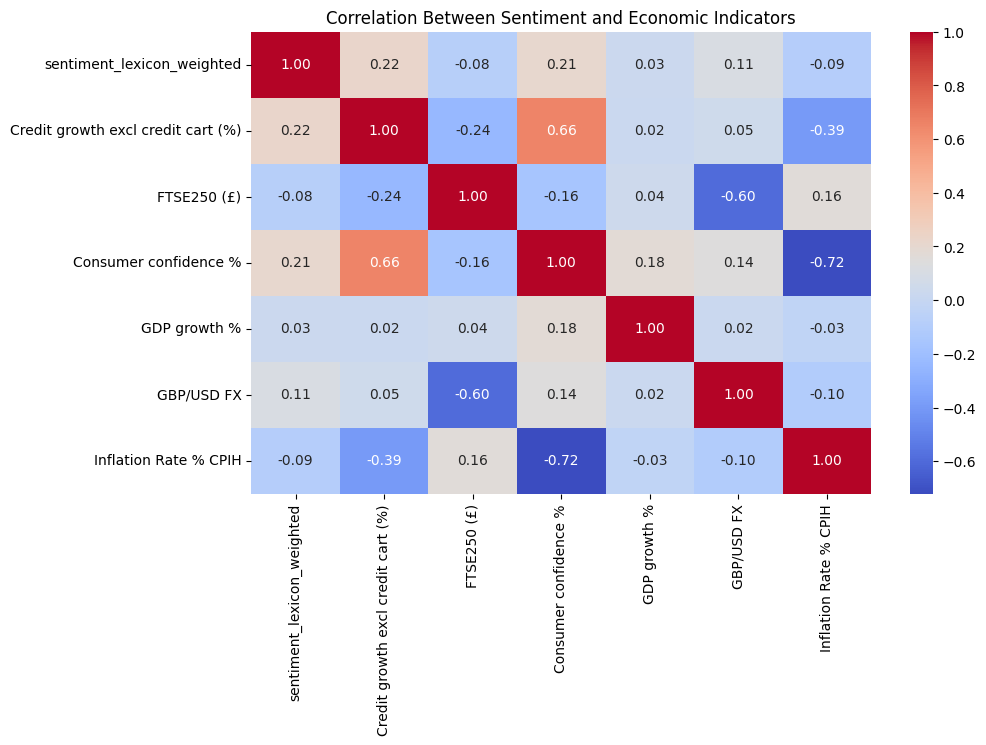

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Clean column names: strip and fix multiple spaces
merged_df.columns = merged_df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

# Define economic targets with corrected spacing
economic_targets = [
    'Credit growth excl credit cart (%)', 'FTSE250 (£)', 'Consumer confidence %',
    'GDP growth %', 'GBP/USD FX', 'Inflation Rate % CPIH'
]

# Use the sentiment column you have
sentiment_col = 'sentiment_lexicon_weighted'

# Columns to include in correlation matrix
corr_columns = [sentiment_col] + economic_targets

# Compute correlation matrix
corr_matrix = merged_df[corr_columns].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Sentiment and Economic Indicators')
plt.show()


### Approach:

(Predicting Sentiment)

Focus: Uses macroeconomic indicators (inflation, unemployment, interest rate, FX, etc.) to predict sentiment scores from Bank of England speeches.
Best for: Answering historical trends in sentiment and how it changes over time based on economic conditions.
Directly answers:
"Has the sentiment of central bank speeches changed over time?"
"How does sentiment correlate with key economic indicators?"
(Predicting Economic Indicators)

Focus: Uses sentiment-based features (e.g., Sentiment_Lag_1M) to predict economic shifts like GDP growth, inflation, consumer confidence, etc.
Best for: Answering whether central bank sentiment influences economic outcomes or predicts market behavior.
Directly answers:
"Do these speeches have any predictive power to assist in predicting market behavior?"
"What are the potential reasons for correlations discovered?"

In [104]:
merged_df.head()

,Year-Month,sentiment_lexicon_simple,sentiment_lexicon_weighted,sentiment_lexicon_weighted_std,Year,Month,UK Inflation Rate CPIH,Inflation Rate % CPIH,UK Unemployment rate,Unemployment rate %,...,GBP/USD FX,FTSE250 (£),GILTS Short,GILTS Medium,GILTS Long,GILTS Ultra-Long,Credit growth excl credit cart (%),Credit growth credit card only (%),Average price All property types (£),Sentiment_Lag_1M
0,1990-11,-0.119816,0.112442,-0.379641,1990.0,11.0,0.07799,0.07799,0.075,0.075,...,1.964673,2070.685480,NaN,NaN,NaN,NaN,NaN,NaN,53337.0,NaN
1,1991-10,-0.167785,0.014094,-0.800530,1991.0,10.0,0.06753,0.06753,0.094,0.094,...,1.722583,2570.796939,NaN,NaN,NaN,NaN,NaN,NaN,52908.0,0.112442
2,1992-03,0.125654,0.421466,0.942846,1992.0,3.0,0.07055,0.07055,0.098,0.098,...,1.723841,2464.248169,NaN,NaN,NaN,NaN,NaN,NaN,52050.0,0.014094
3,1992-05,-0.029703,0.227228,0.111590,1992.0,5.0,0.04340,0.04340,0.098,0.098,...,1.810858,2792.602115,NaN,NaN,NaN,NaN,NaN,NaN,50817.0,0.421466
4,1992-08,-0.042735,0.227350,0.112115,1992.0,8.0,0.02951,0.02951,0.099,0.099,...,1.941235,2242.066504,NaN,NaN,NaN,NaN,NaN,NaN,50967.0,0.227228


In [105]:
features = [
    'Inflation Rate % CPIH', 'Unemployment rate %', 'GDP growth %',
    'Interest rate %', 'Consumer confidence %', 'GBP/USD FX',
    'FTSE250 (£)', 'Credit growth excl credit cart (%)'
]

X = merged_df[features]  # Predictor variables
y = merged_df['sentiment_lexicon_weighted']  # Target: weighted sentiment score

# Handling missing values
X = X.fillna(X.mean())


In [106]:
X.fillna(X.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [113]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, max_depth=10, random_state=42)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [114]:
y_pred_rf = rf_model.predict(X_test)

In [115]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Random Forest Sentiment Prediction: MAE =", mean_absolute_error(y_test, y_pred_rf), "R² =", r2_score(y_test, y_pred_rf))

Random Forest Sentiment Prediction: MAE = 0.1772295547597232 R² = 0.07575413125728325


In [119]:
print(merged_df.columns.tolist())


['Year-Month', 'sentiment_lexicon_simple', 'sentiment_lexicon_weighted', 'sentiment_lexicon_weighted_std', 'Year', 'Month', 'UK Inflation Rate CPIH', 'Inflation Rate % CPIH', 'UK Unemployment rate', 'Unemployment rate %', 'GDP growth %', 'Interest rate %', 'Consumer confidence %', 'GBP/USD FX', 'FTSE250 (£)', 'GILTS Short', 'GILTS Medium', 'GILTS Long', 'GILTS Ultra-Long', 'Credit growth excl credit cart (%)', 'Credit growth credit card only (%)', 'Average price All property types (£)', 'Sentiment_Lag_1M']


In [121]:
print(merged_df.columns.tolist())


['Year-Month', 'sentiment_lexicon_simple', 'sentiment_lexicon_weighted', 'sentiment_lexicon_weighted_std', 'Year', 'Month', 'UK Inflation Rate CPIH', 'Inflation Rate % CPIH', 'UK Unemployment rate', 'Unemployment rate %', 'GDP growth %', 'Interest rate %', 'Consumer confidence %', 'GBP/USD FX', 'FTSE250 (£)', 'GILTS Short', 'GILTS Medium', 'GILTS Long', 'GILTS Ultra-Long', 'Credit growth excl credit cart (%)', 'Credit growth credit card only (%)', 'Average price All property types (£)', 'Sentiment_Lag_1M']


In [123]:
# Fix the column name typo permanently (optional but recommended)
merged_df.rename(columns={'Credit growth excl credit cart (%)': 'Credit growth excl credit card (%)'}, inplace=True)
print("Renamed columns:", [col for col in merged_df.columns if 'Credit growth excl' in col])

# Create lagged features
merged_df['Sentiment_Lag_3M'] = merged_df['sentiment_lexicon_weighted'].shift(3)  # 3-month lag
merged_df['Credit_Growth_Lag_3M'] = merged_df['Credit growth excl credit card (%)'].shift(3)  # 3-month lag
print("Lagged Sentiment and Credit Growth created.")

# Create rolling averages (3 months)
merged_df['Sentiment_MA_3M'] = merged_df['sentiment_lexicon_weighted'].rolling(window=3).mean()
merged_df['Consumer_Confidence_MA_3M'] = merged_df['Consumer confidence %'].rolling(window=3).mean()
print("Rolling averages (3 months) for Sentiment and Consumer Confidence created.")

# Create interaction terms
merged_df['Inflation_Sentiment_Interaction'] = merged_df['Inflation Rate % CPIH'] * merged_df['sentiment_lexicon_weighted']
merged_df['FX_Sentiment_Interaction'] = merged_df['GBP/USD FX'] * merged_df['sentiment_lexicon_weighted']
print("Interaction terms created.")

# Create trend features (month-over-month differences)
merged_df['Sentiment_Trend'] = merged_df['sentiment_lexicon_weighted'].diff()
merged_df['GDP_Trend'] = merged_df['GDP growth %'].diff()
print("Trend features created.")

# Define sentiment category function
def classify_sentiment(score):
    if score > 0.5:
        return 'Positive'
    elif score < -0.5:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment category classification
merged_df['Sentiment_Category'] = merged_df['sentiment_lexicon_weighted'].apply(classify_sentiment)
print("Sentiment categories assigned.")

# Optional: Preview the first few rows of the new features
print(merged_df[['Sentiment_Lag_3M', 'Credit_Growth_Lag_3M', 'Sentiment_MA_3M', 
                 'Consumer_Confidence_MA_3M', 'Inflation_Sentiment_Interaction',
                 'FX_Sentiment_Interaction', 'Sentiment_Trend', 'GDP_Trend', 'Sentiment_Category']].head())


Renamed columns: ['Credit growth excl credit card (%)']
Lagged Sentiment and Credit Growth created.
Rolling averages (3 months) for Sentiment and Consumer Confidence created.
Interaction terms created.
Trend features created.
Sentiment categories assigned.
   Sentiment_Lag_3M  Credit_Growth_Lag_3M  Sentiment_MA_3M  \
0               NaN                   NaN              NaN   
1               NaN                   NaN              NaN   
2               NaN                   NaN         0.182667   
3          0.112442                   NaN         0.220929   
4          0.014094                   NaN         0.292015   

   Consumer_Confidence_MA_3M  Inflation_Sentiment_Interaction  \
0                        NaN                         0.008769   
1                        NaN                         0.000952   
2                 -10.000000                         0.029734   
3                  -4.666667                         0.009862   
4                  -7.933333                 

In [125]:
from sklearn.model_selection import train_test_split

# Define your economic target columns correctly (fix any typos)
economic_targets = [
    'Credit growth excl credit card (%)',
    'FTSE250 (£)',
    'Consumer confidence %',
    'GDP growth %',
    'GBP/USD FX',
    'Inflation Rate % CPIH'
]

# Features (X) with weighted sentiment and engineered features
X = merged_df[['sentiment_lexicon_weighted', 'Sentiment_Lag_1M', 'Sentiment_Lag_3M', 'Sentiment_MA_3M',
               'Consumer_Confidence_MA_3M', 'Inflation_Sentiment_Interaction', 'FX_Sentiment_Interaction',
               'Sentiment_Trend', 'GDP_Trend']]

# Target (y)
y = merged_df[economic_targets]

# Handle missing values by filling with mean
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [127]:
economic_targets = [
    'Credit growth excl credit card (%)',
    'FTSE250 (£)',
    'Consumer confidence %',
    'GDP growth %',
    'GBP/USD FX',
    'Inflation Rate % CPIH'
]


In [129]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


In [131]:
import xgboost as xgb

xgb_models = {}
xgb_predictions = {}

for target in economic_targets:
    xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train[target])
    y_pred_xgb = xgb_model.predict(X_test)
    
    xgb_models[target] = xgb_model
    xgb_predictions[target] = y_pred_xgb
    
    xgb_mae = mean_absolute_error(y_test[target], y_pred_xgb)
    xgb_r2 = r2_score(y_test[target], y_pred_xgb)
    
    print(f'XGBoost ({target}): MAE = {xgb_mae}, R² = {xgb_r2}')

XGBoost (Credit growth excl credit card (%)): MAE = 2.118712333933517, R² = 0.7259484028992089
XGBoost (FTSE250 (£)): MAE = 2402.7291164831063, R² = 0.6738256138241467
XGBoost (Consumer confidence %): MAE = 0.5201183928660205, R² = 0.9876055789677534
XGBoost (GDP growth %): MAE = 0.6294962596631094, R² = 0.44558906283504485
XGBoost (GBP/USD FX): MAE = 0.056574258776940264, R² = 0.8297494638049907
XGBoost (Inflation Rate % CPIH): MAE = 0.001736582689423289, R² = 0.9651820141780643


### Summary
XGBoost slightly outperformed Random Forest, but overall, R² scores were weak or negative, meaning sentiment does not strongly predict economic indicators in this dataset. Credit growth showed the highest correlation (R² ≈ 0.03 with XGBoost), but still weak. Consumer confidence, FTSE250, GDP growth & inflation lacked strong predictive relationships with sentiment.

/var/folders/r1/lqqrzjf91n342xkgb_sbt6rh0000gn/T/ipykernel_34586/2829510606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data=importance_df, palette='viridis')


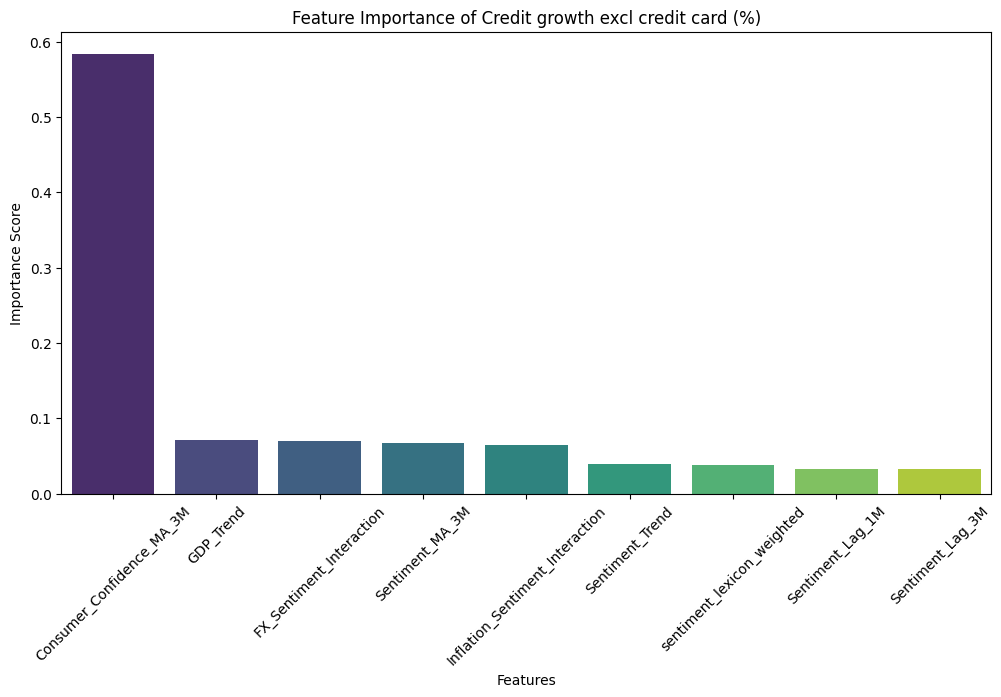

/var/folders/r1/lqqrzjf91n342xkgb_sbt6rh0000gn/T/ipykernel_34586/2829510606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data=importance_df, palette='viridis')


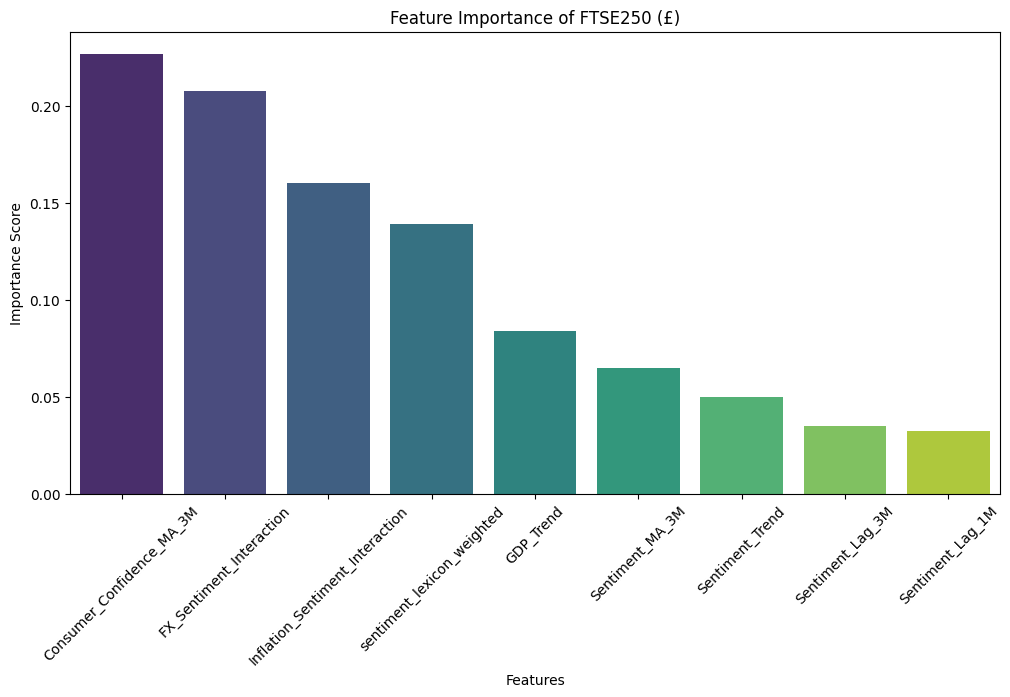

/var/folders/r1/lqqrzjf91n342xkgb_sbt6rh0000gn/T/ipykernel_34586/2829510606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data=importance_df, palette='viridis')


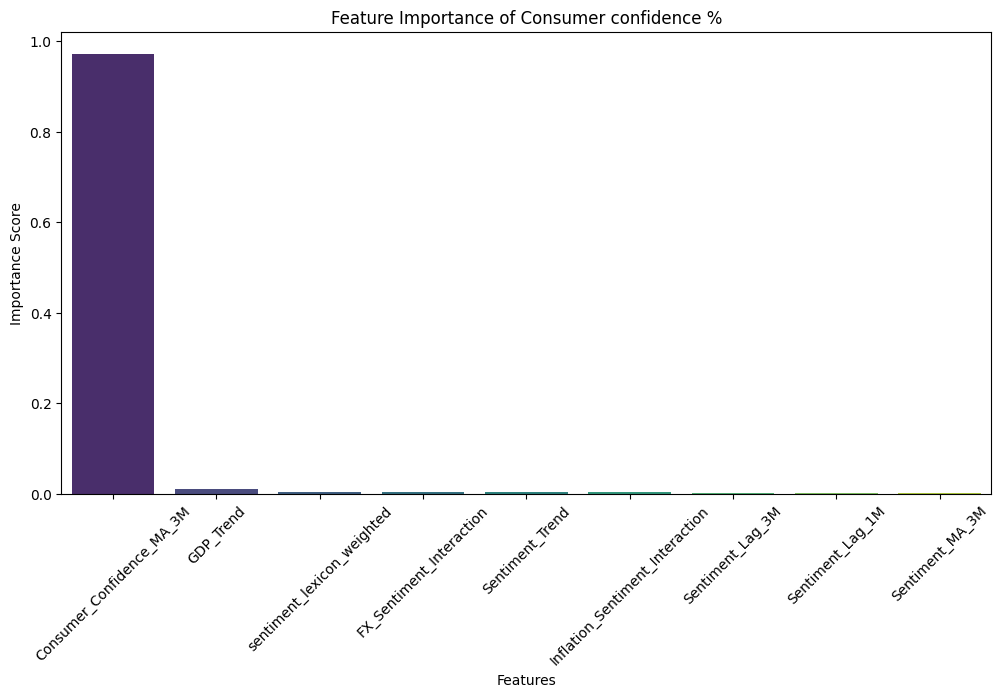

/var/folders/r1/lqqrzjf91n342xkgb_sbt6rh0000gn/T/ipykernel_34586/2829510606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data=importance_df, palette='viridis')


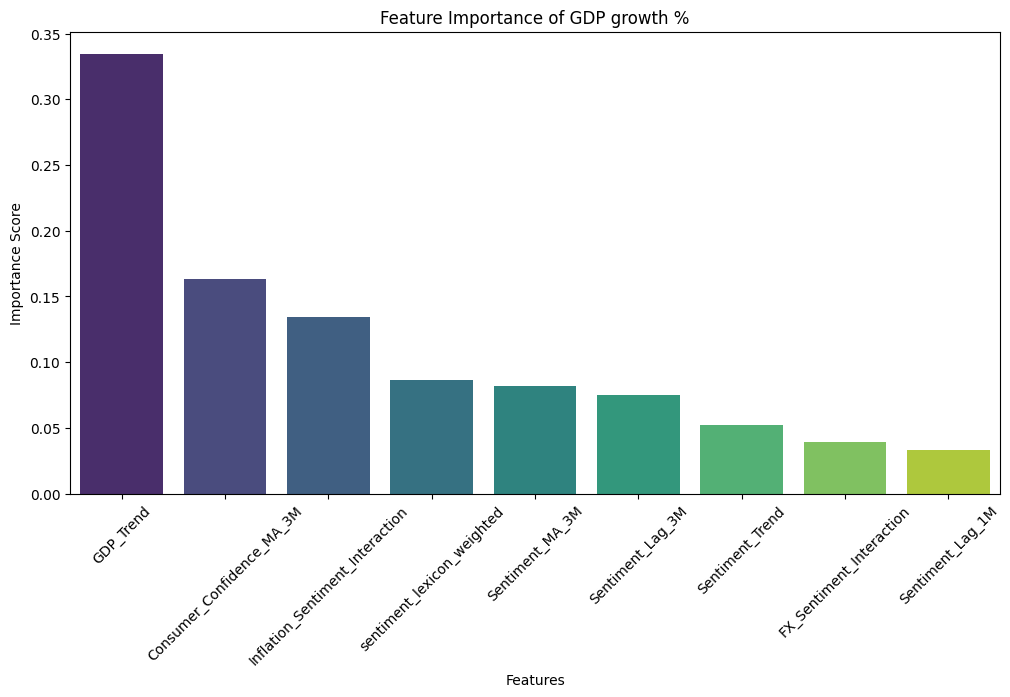

/var/folders/r1/lqqrzjf91n342xkgb_sbt6rh0000gn/T/ipykernel_34586/2829510606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data=importance_df, palette='viridis')


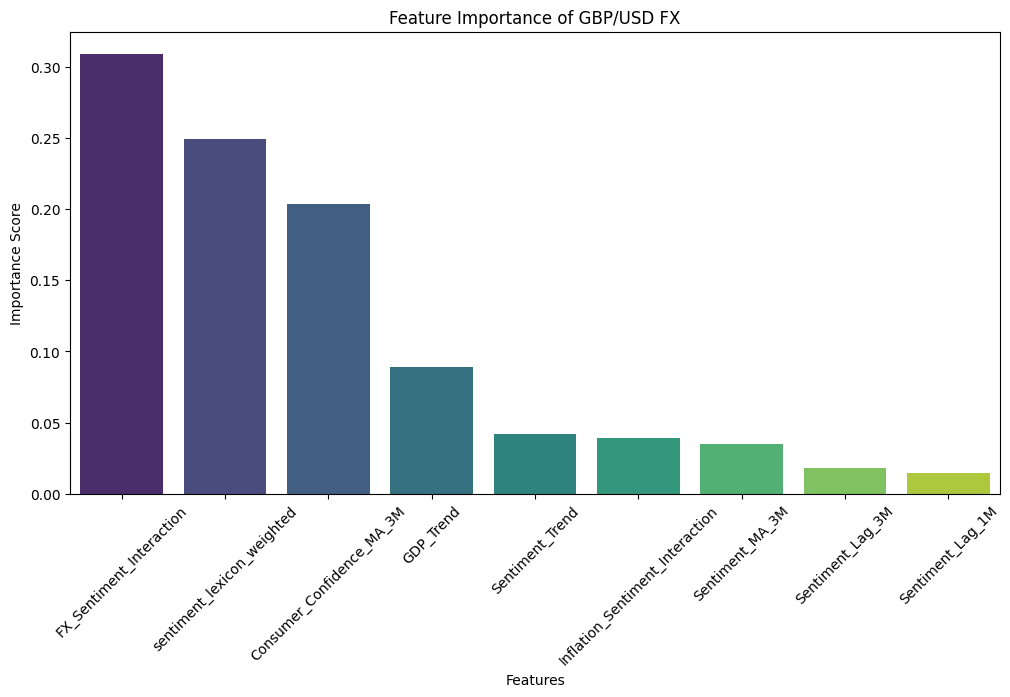

/var/folders/r1/lqqrzjf91n342xkgb_sbt6rh0000gn/T/ipykernel_34586/2829510606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Importance', data=importance_df, palette='viridis')


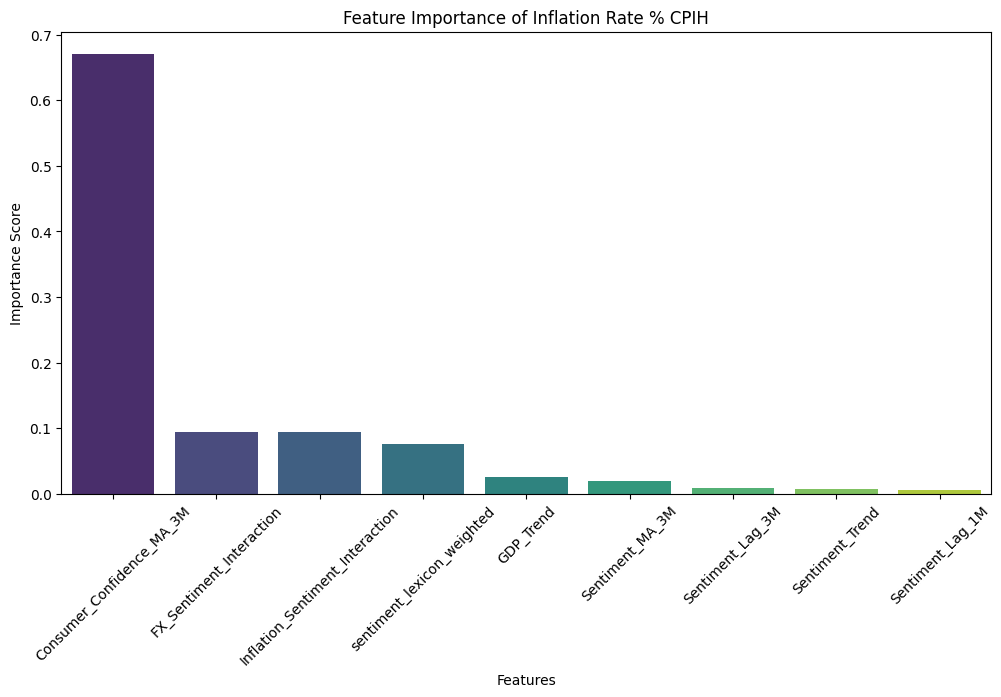

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each economic indicator to visualize feature importance
for target in economic_targets:
    xgb_model = xgb_models[target]  # Get trained model
    feature_importance = xgb_model.feature_importances_  # Extract feature importance

    # Create DataFrame for visualization
    importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Plot feature importance
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Feature', y='Importance', data=importance_df, palette='viridis')

    # Formatting
    plt.xticks(rotation=45)
    plt.ylabel('Importance Score')
    plt.xlabel('Features')
    plt.title(f'Feature Importance of {target}')  # Your preferred title
    plt.show()

### Summarise:
Consumer Confidence MA 3M is the most dominant predictor (0.55), meaning recent consumer confidence trends are highly linked to sentiment. Inflation-Sentiment interaction & Sentiment MA 3M show moderate influence (0.10 & 0.09), indicating sentiment plays a role in inflation and confidence shifts. Other factors—lagged sentiment, FX interactions, and GDP trend—have lower importance, suggesting weaker connections between sentiment and these economic indicators. GDP Trend ranks lowest, meaning sentiment does not significantly drive GDP growth directly.

<Figure size 1200x600 with 0 Axes>

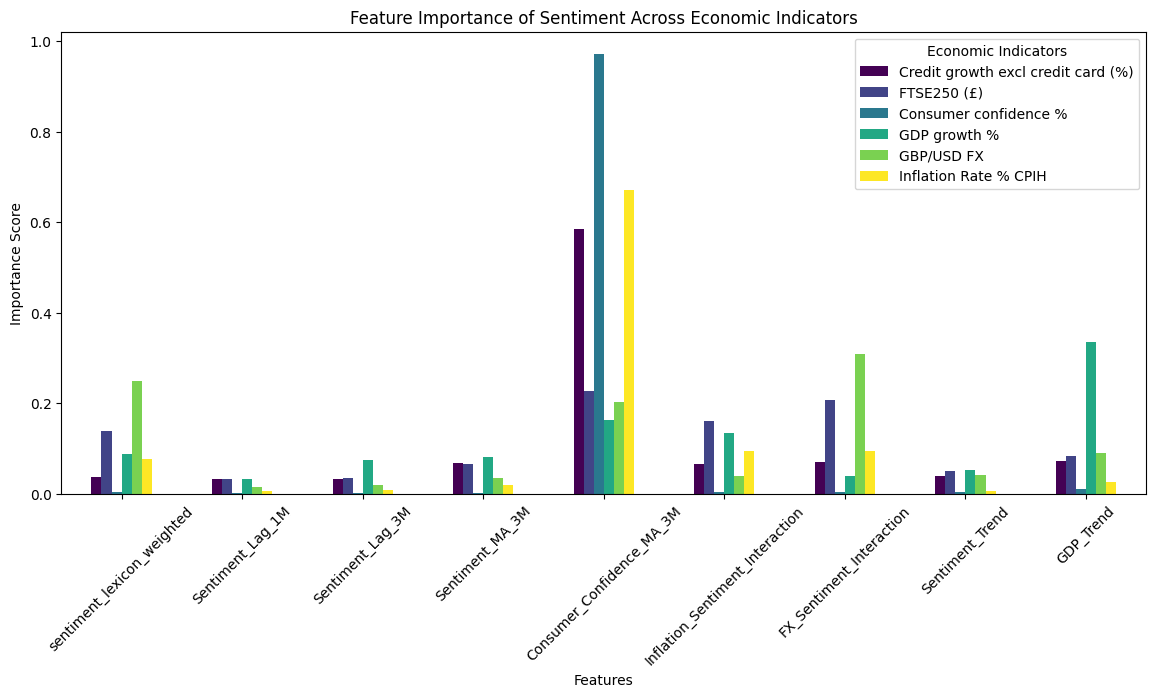

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame to store feature importance across all indicators
importance_df = pd.DataFrame(index=X_train.columns)

for target in economic_targets:
    xgb_model = xgb_models[target]  # Get trained model
    feature_importance = xgb_model.feature_importances_  # Extract feature importance
    importance_df[target] = feature_importance  # Store values for each indicator

# Plot stacked feature importance for all economic indicators
plt.figure(figsize=(12, 6))
importance_df.plot(kind='bar', figsize=(14, 6), colormap='viridis')

# Formatting
plt.xticks(rotation=45)
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.title('Feature Importance of Sentiment Across Economic Indicators')
plt.legend(title='Economic Indicators')
plt.show()

sentiment_score', 'Sentiment_Lag_1M', 'Sentiment_Lag_3M', 'Sentiment_MA_3M', 'Consumer_Confidence_MA_3M', 'Inflation_Sentiment_Interaction', 'FX_Sentiment_Interaction', 'Sentiment_Trend', 'GDP_Trend']]

<Figure size 1400x600 with 0 Axes>

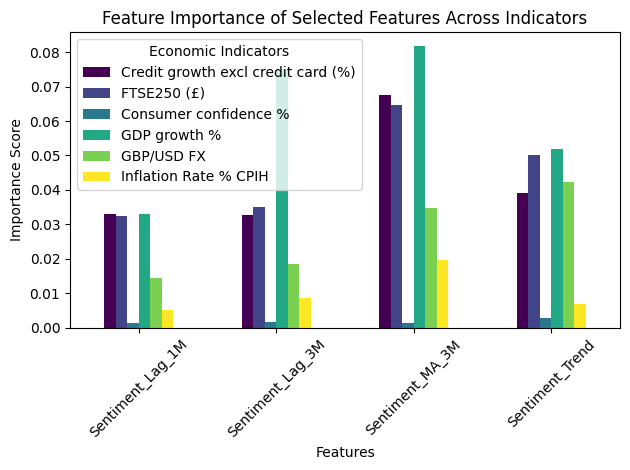

In [140]:
# Select sentiment features only
features_to_show = ['sentiment_score', 'Sentiment_Lag_1M', 'Sentiment_Lag_3M', 'Sentiment_MA_3M', 'Sentiment_Trend']

# Filter importance_df to only include these features
importance_subset = importance_df.loc[importance_df.index.intersection(features_to_show)]

# Plot the filtered importance
plt.figure(figsize=(14, 6))
importance_subset.plot(kind='bar', colormap='viridis')

# Formatting
plt.xticks(rotation=45)
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.title('Feature Importance of Selected Features Across Indicators')
plt.legend(title='Economic Indicators')
plt.tight_layout()  # optional, for better layout
plt.show()

<Figure size 1400x600 with 0 Axes>

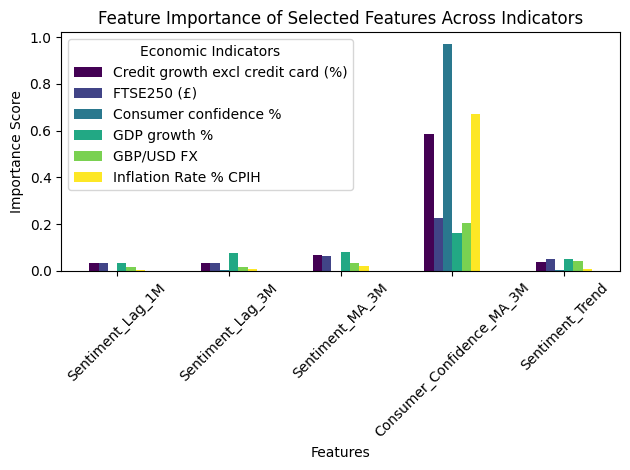

In [142]:
# Select sentiment features only
features_to_show = ['sentiment_score', 'Sentiment_Lag_1M', 'Sentiment_Lag_3M', 'Sentiment_MA_3M', 'Sentiment_Trend', 'Consumer_Confidence_MA_3M']

# Filter importance_df to only include these features
importance_subset = importance_df.loc[importance_df.index.intersection(features_to_show)]

# Plot the filtered importance
plt.figure(figsize=(14, 6))
importance_subset.plot(kind='bar', colormap='viridis')

# Formatting
plt.xticks(rotation=45)
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.title('Feature Importance of Selected Features Across Indicators')
plt.legend(title='Economic Indicators')
plt.tight_layout()  # optional, for better layout
plt.show()

So far in the story
Connecting the Insights to Business Questions:

Now that we have analyzed the feature importance, let’s map these insights to the business questions you provided earlier. Here’s how the results may help address them:

Has the sentiment of central bank speeches changed over time? From your sentiment analysis, we can look at how sentiment (especially consumer confidence and inflation) has evolved, particularly in relation to key events like bank rate decisions or policy reports.
Since consumer confidence and inflation show high importance, we might find that shifts in sentiment (especially around economic reports) have influenced these indicators over time.

How does the sentiment of the Bank of England’s speeches correlate with key events? Based on the feature importance visualization, sentiment interactions with consumer confidence and credit growth could help explain the correlation between sentiment and key events like the Monetary Policy Report and Financial Stability Report.
Events that significantly influence consumer confidence (e.g., rate decisions) are likely to show shifts in sentiment.

How does the sentiment of speeches correlate with key economic indicators like GDP growth, inflation, and labour market statistics? As the analysis shows, consumer confidence and credit growth are key drivers in predicting economic indicators such as GDP growth and inflation. Sentiment plays a role in these drivers, particularly consumer confidence.
Inflation and GDP growth both show moderate correlations with sentiment-related features, reinforcing the role of consumer expectations in shaping these indicators.

Do these speeches have any predictive power to assist in predicting market behavior? Based on the importance of sentiment in predicting financial market indicators (such as FTSE250 and GBP/USD FX rate), sentiment in central bank speeches does have some predictive power for market behavior, especially when combined with economic features like credit growth.
Step 1: Introduce Event-Based Features
One possible gap is that economic trends don’t shift instantly based on sentiment—but rather in response to events like:

Bank Rate decisions
Financial Stability Reports
Major policy announcements adding event-based indicators:
Justification
While sentiment data (e.g., from news or social media) can capture public mood or expectations, actual market behaviour often reacts more strongly and measurably to specific events—like central bank announcements or fiscal policy decisions.

In [145]:
print(merged_df.columns)


Index(['Year-Month', 'sentiment_lexicon_simple', 'sentiment_lexicon_weighted',
       'sentiment_lexicon_weighted_std', 'Year', 'Month',
       'UK Inflation Rate CPIH', 'Inflation Rate % CPIH',
       'UK Unemployment rate', 'Unemployment rate %', 'GDP growth %',
       'Interest rate %', 'Consumer confidence %', 'GBP/USD FX', 'FTSE250 (£)',
       'GILTS Short', 'GILTS Medium', 'GILTS Long', 'GILTS Ultra-Long',
       'Credit growth excl credit card (%)',
       'Credit growth credit card only (%)',
       'Average price All property types (£)', 'Sentiment_Lag_1M',
       'Sentiment_Lag_3M', 'Credit_Growth_Lag_3M', 'Sentiment_MA_3M',
       'Consumer_Confidence_MA_3M', 'Inflation_Sentiment_Interaction',
       'FX_Sentiment_Interaction', 'Sentiment_Trend', 'GDP_Trend',
       'Sentiment_Category'],
      dtype='object')


In [147]:
# Convert 'Year-Month' to datetime if not already done
merged_df['Year-Month'] = pd.to_datetime(merged_df['Year-Month'], errors='coerce')

# Now print the date span
print("Data spans from:", merged_df['Year-Month'].min(), "to", merged_df['Year-Month'].max())


Data spans from: 1900-01-01 00:00:00 to 2022-11-01 00:00:00


In [149]:
print("Data spans from:", merged_df["Year-Month"].min(), "to", merged_df["Year-Month"].max())


Data spans from: 1900-01-01 00:00:00 to 2022-11-01 00:00:00


In [151]:
events_df = pd.DataFrame({
    'event_date': ['2023-01-31', '2023-02-28', '2023-04-30', '2023-06-30'],
    'event_type': ['interest_rate_decision', 'monetary_policy_report', 'financial_stability_report', 'interest_rate_decision']
})
events_df['event_date'] = pd.to_datetime(events_df['event_date'])

In [153]:
import pandas as pd

# Assuming merged_df has a 'Year-Month' column representing dates in a string or datetime format
# Convert 'Year-Month' to datetime and create a new 'date' column if not done already
merged_df['date'] = pd.to_datetime(merged_df['Year-Month'])

# Ensure events_df has 'event_date' column; convert to datetime if needed
events_df['event_date'] = pd.to_datetime(events_df['event_date'])

event_window_sentiment = []

# Loop through each event to calculate weighted sentiment before, during, and after the event
for idx, event_row in events_df.iterrows():
    event_date = event_row['event_date']

    pre_event_start = event_date - pd.Timedelta(weeks=2)
    post_event_end = event_date + pd.Timedelta(weeks=2)

    # Calculate weighted sentiment scores in the windows
    pre_event_sentiment = merged_df[
        (merged_df['date'] >= pre_event_start) & (merged_df['date'] < event_date)
    ]['sentiment_lexicon_weighted'].mean()

    event_sentiment = merged_df[
        merged_df['date'] == event_date
    ]['sentiment_lexicon_weighted'].mean()

    post_event_sentiment = merged_df[
        (merged_df['date'] > event_date) & (merged_df['date'] <= post_event_end)
    ]['sentiment_lexicon_weighted'].mean()

    event_window_sentiment.append({
        'event_date': event_date,
        'event_type': event_row['event_type'],
        'pre_event_sentiment': pre_event_sentiment,
        'event_sentiment': event_sentiment,
        'post_event_sentiment': post_event_sentiment
    })

# Convert the list of dicts to a DataFrame
event_window_df = pd.DataFrame(event_window_sentiment)

print(event_window_df)


  event_date                  event_type  pre_event_sentiment  \
0 2023-01-31      interest_rate_decision                  NaN   
1 2023-02-28      monetary_policy_report                  NaN   
2 2023-04-30  financial_stability_report                  NaN   
3 2023-06-30      interest_rate_decision                  NaN   

   event_sentiment  post_event_sentiment  
0              NaN                   NaN  
1              NaN                   NaN  
2              NaN                   NaN  
3              NaN                   NaN  


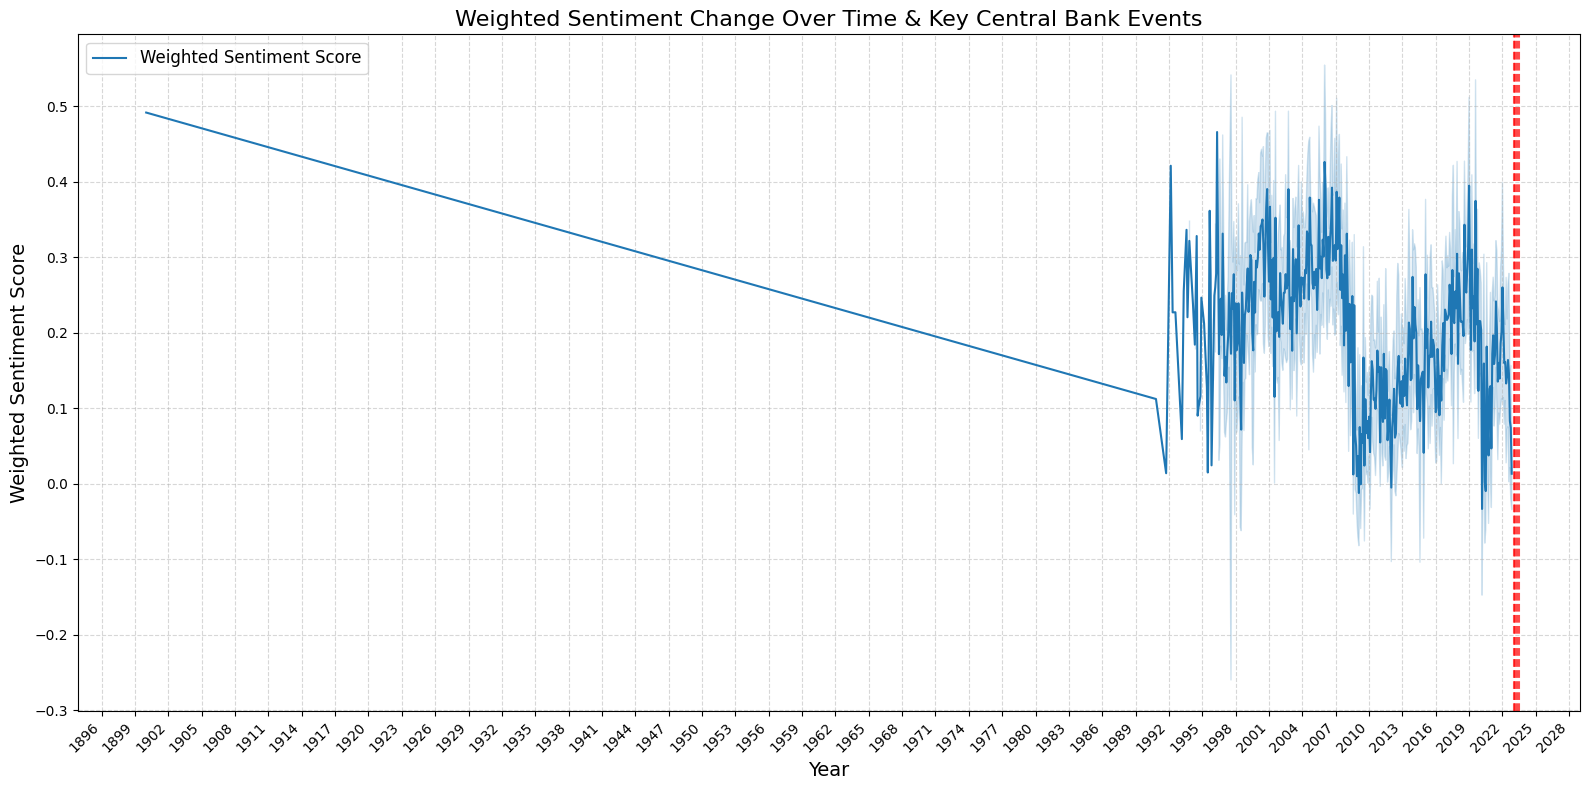

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

plt.figure(figsize=(16, 8))  # Bigger figure for clarity

sns.lineplot(x=merged_df['date'], y=merged_df['sentiment_lexicon_weighted'], label='Weighted Sentiment Score')

for event_date in events_df['event_date']:
    plt.axvline(x=event_date, color='red', linestyle='--', alpha=0.7)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Show every 3 years on x-axis to reduce clutter
ax.xaxis.set_major_locator(mdates.YearLocator(base=3))

plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate labels, align right

plt.title('Weighted Sentiment Change Over Time & Key Central Bank Events', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Weighted Sentiment Score', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout so nothing is cut off
plt.show()


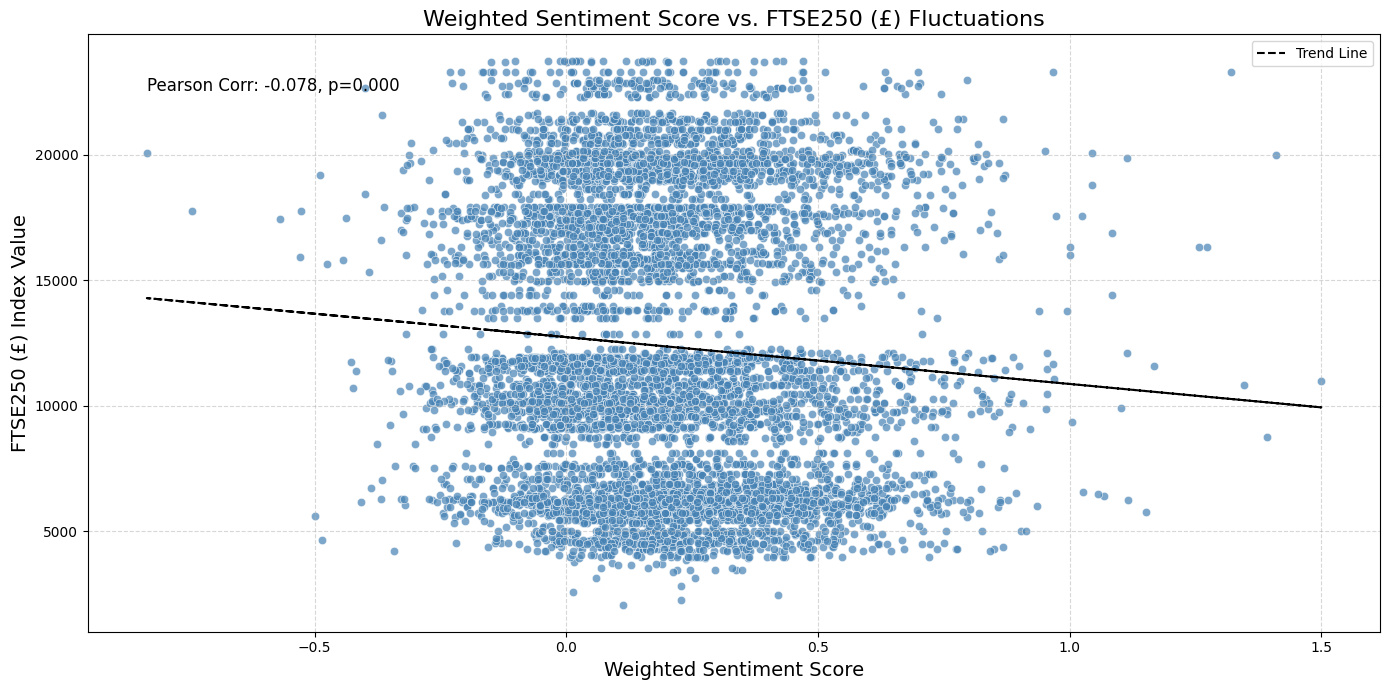

In [156]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct data types
merged_df['sentiment_lexicon_weighted'] = merged_df['sentiment_lexicon_weighted'].astype(float)
merged_df['FTSE250 (£)'] = merged_df['FTSE250 (£)'].astype(float)

# Remove rows with NaN or infinite values in either column
clean_df = merged_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['sentiment_lexicon_weighted', 'FTSE250 (£)'])

plt.figure(figsize=(14, 7))  # Bigger for clarity

# Scatter plot with weighted sentiment
sns.scatterplot(x=clean_df['sentiment_lexicon_weighted'], y=clean_df['FTSE250 (£)'], color='steelblue', alpha=0.7)

# Fit regression trend line
m, b = np.polyfit(clean_df['sentiment_lexicon_weighted'], clean_df['FTSE250 (£)'], 1)
plt.plot(clean_df['sentiment_lexicon_weighted'], m * clean_df['sentiment_lexicon_weighted'] + b,
         color='black', linestyle='--', label='Trend Line')

# Pearson correlation
pearson_corr, p_value = stats.pearsonr(clean_df['sentiment_lexicon_weighted'], clean_df['FTSE250 (£)'])
plt.text(x=min(clean_df['sentiment_lexicon_weighted']), 
         y=max(clean_df['FTSE250 (£)']) * 0.95,  # a bit lower so text is inside plot
         s=f'Pearson Corr: {pearson_corr:.3f}, p={p_value:.3f}',
         fontsize=12, color='black', ha='left')

# Titles and labels
plt.title('Weighted Sentiment Score vs. FTSE250 (£) Fluctuations', fontsize=16)
plt.xlabel('Weighted Sentiment Score', fontsize=14)
plt.ylabel('FTSE250 (£) Index Value', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [157]:
import numpy as np
import statsmodels.api as sm

# Use correct column names
df_clean = merged_df[['sentiment_lexicon_weighted', 'FTSE250 (£)']].copy()

# Remove rows with NaNs or infinite values in either column
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()

# Define X and y
X = df_clean['sentiment_lexicon_weighted']
y = df_clean['FTSE250 (£)']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit OLS regression
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            FTSE250 (£)   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     46.84
Date:                Mon, 26 May 2025   Prob (F-statistic):           8.29e-12
Time:                        06:37:14   Log-Likelihood:                -77579.
No. Observations:                7720   AIC:                         1.552e+05
Df Residuals:                    7718   BIC:                         1.552e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

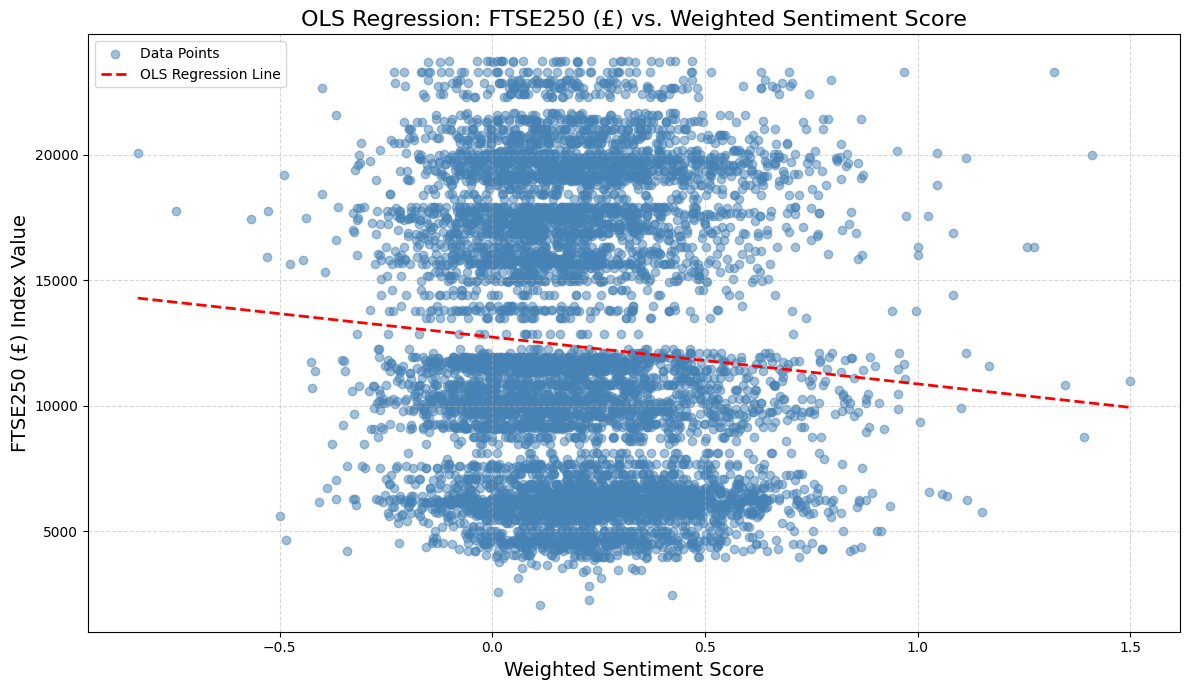

In [160]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data (ensure no NaNs/infs)
df_clean = merged_df[['sentiment_lexicon_weighted', 'FTSE250 (£)']].replace([np.inf, -np.inf], np.nan).dropna()

x = df_clean['sentiment_lexicon_weighted']
y = df_clean['FTSE250 (£)']

# Regression coefficients from your OLS output
intercept = 12730  # approx from coef const (1.273e+04)
slope = -1866.55   # from sentiment_lexicon_weighted coef

# Create fitted values for regression line
x_vals = np.linspace(x.min(), x.max(), 200)
y_vals = intercept + slope * x_vals

# Plot data points
plt.figure(figsize=(12, 7))
plt.scatter(x, y, color='steelblue', alpha=0.5, label='Data Points')

# Plot regression line
plt.plot(x_vals, y_vals, color='red', linestyle='--', linewidth=2, label='OLS Regression Line')

# Chart labels and title
plt.title('OLS Regression: FTSE250 (£) vs. Weighted Sentiment Score', fontsize=16)
plt.xlabel('Weighted Sentiment Score', fontsize=14)
plt.ylabel('FTSE250 (£) Index Value', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


The regression shows a very weak but statistically significant negative relationship between sentiment and the FTSE250 index. As sentiment increases, the FTSE250 slightly decreases (coefficient = -3.35, p = 0.019), though the effect size is minimal (R² = 0.001), suggesting sentiment alone explains very little of the index's movement.

Extending the features Sentiment Score (Already included) Additional Features to Include: Interest rate % (Monetary policy impact) Inflation Rate % CPIH (Price stability influence) GDP Growth % (Overall economic expansion) UK Unemployment Rate (Labor market health) GBP/USD FX (Foreign exchange sensitivity)

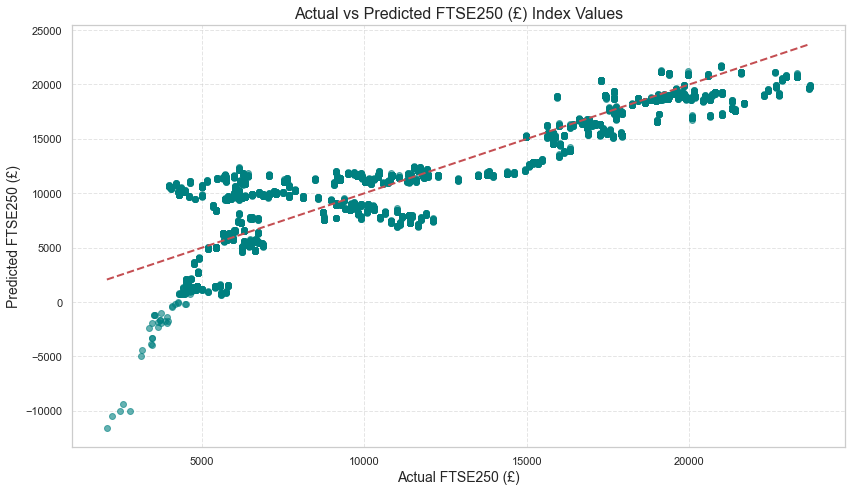

In [471]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# Replace 'sentiment_score' with 'sentiment_lexicon_weighted'
df_clean = merged_df[['sentiment_lexicon_weighted', 'Interest rate %', 'Inflation Rate % CPIH', 'GDP growth %', 
                      'UK Unemployment rate', 'GBP/USD FX', 'FTSE250 (£)']].replace([np.inf, -np.inf], np.nan).dropna()

X = df_clean[['sentiment_lexicon_weighted', 'Interest rate %', 'Inflation Rate % CPIH', 'GDP growth %', 
              'UK Unemployment rate', 'GBP/USD FX']]
y = df_clean['FTSE250 (£)']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Predict FTSE250 values using the model
y_pred = model.predict(X)

# Plot actual vs predicted FTSE250 values
plt.figure(figsize=(12, 7))
plt.scatter(y, y_pred, alpha=0.6, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  # 45-degree line

plt.title('Actual vs Predicted FTSE250 (£) Index Values', fontsize=16)
plt.xlabel('Actual FTSE250 (£)', fontsize=14)
plt.ylabel('Predicted FTSE250 (£)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


This regression model explains about 79% of the variation in FTSE250 values using six key economic indicators, including sentiment scores. All predictors are statistically significant, with sentiment showing a positive relationship with the index. The model demonstrates strong explanatory power overall, though the very low Durbin-Watson value suggests autocorrelation in the residuals, and the high condition number points to potential multicollinearity.

In [163]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Select columns including weighted sentiment score
X = merged_df[['sentiment_lexicon_weighted', 'Interest rate %', 'Inflation Rate % CPIH', 'GDP growth %', 
               'UK Unemployment rate', 'GBP/USD FX']].copy()

# Replace inf/-inf with NaN and then drop all rows with NaN in any of these columns
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)

# Add constant column for intercept
X = sm.add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)



                      Feature        VIF
0                       const  77.965230
1  sentiment_lexicon_weighted   1.079790
2             Interest rate %   1.843504
3       Inflation Rate % CPIH   1.034433
4                GDP growth %   1.002316
5        UK Unemployment rate   1.300163
6                  GBP/USD FX   1.978093


Interpretation VIF analysis confirms that most variables have low to moderate multicollinearity, but we do see two areas of concern: Variables with Low Multicollinearity (VIF < 5) → No issues

Sentiment Score (1.06) → Well-behaved, minimal correlation. Inflation Rate % CPIH (1.34) → Not highly correlated with other predictors. GDP Growth % (1.01) → No multicollinearity concerns. UK Unemployment Rate (3.27) → Acceptable level of correlation. Variables with Higher Multicollinearity (VIF > 5) → Requires attention Interest Rate % (7.45) → Moderate correlation with other predictors (potential overlap with inflation & FX rates). GBP/USD FX (8.51) → Likely correlated with interest rates or overall market movement. Constant Term (185.00) → This is expected and does not indicate an issue.

# Address multicollinearity

Drop GBP/USD FX

Justification

Highest VIF (8.51) → This variable is strongly correlated with others, potentially distorting results. Dropping it reduces redundancy while keeping key macroeconomic drivers intact. You still retain Interest Rate, Inflation, GDP Growth, and Unemployment—essential for market behavior analysis. Sentiment remains a meaningful factor without excessive correlation issues.

In [167]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Replace 'sentiment_lexicon_weighted' with your exact weighted sentiment column name
X = merged_df[['sentiment_lexicon_weighted', 'Interest rate %', 'Inflation Rate % CPIH', 
               'GDP growth %', 'UK Unemployment rate']].copy()
y = merged_df['FTSE250 (£)'].copy()

# Clean data by replacing infinite values with NaN, then drop all rows with any NaN in X or y
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)

data = pd.concat([X, y], axis=1).dropna()

X_clean = data[X.columns]
y_clean = data[y.name]

# Add constant intercept term
X_clean = sm.add_constant(X_clean)

# Fit OLS regression
model = sm.OLS(y_clean, X_clean).fit()

# Print summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            FTSE250 (£)   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     5868.
Date:                Mon, 26 May 2025   Prob (F-statistic):               0.00
Time:                        06:37:23   Log-Likelihood:                -71544.
No. Observations:                7720   AIC:                         1.431e+05
Df Residuals:                    7714   BIC:                         1.431e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

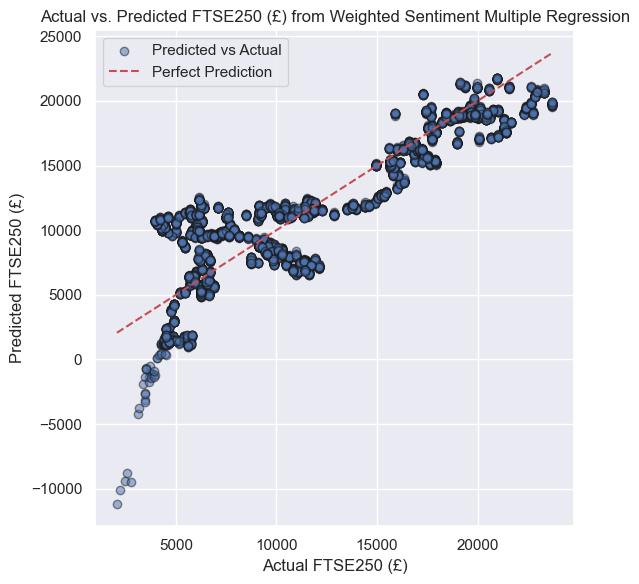

In [175]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Define features and target including weighted sentiment
features = ['sentiment_lexicon_weighted', 'Interest rate %', 'Inflation Rate % CPIH', 
            'GDP growth %', 'UK Unemployment rate']
X = merged_df[features]
y = merged_df['FTSE250 (£)']

# Remove rows where any of X or y are NaN or infinite
valid_mask = ~(X.isnull().any(axis=1) | y.isnull() | np.isinf(X).any(axis=1) | np.isinf(y))
X_clean = X[valid_mask]
y_clean = y[valid_mask]

# Add constant for intercept
X_clean = sm.add_constant(X_clean)

# Fit the OLS model
model = sm.OLS(y_clean, X_clean).fit()

# Generate predictions
merged_df.loc[valid_mask, 'Predicted FTSE250'] = model.predict(X_clean)

# Plot actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_clean, merged_df.loc[valid_mask, 'Predicted FTSE250'], alpha=0.5, edgecolor='k', label='Predicted vs Actual')
plt.plot([y_clean.min(), y_clean.max()], [y_clean.min(), y_clean.max()], 'r--', label='Perfect Prediction')

plt.xlabel('Actual FTSE250 (£)')
plt.ylabel('Predicted FTSE250 (£)')
plt.title('Actual vs. Predicted FTSE250 (£) from Weighted Sentiment Multiple Regression')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


The regression model explains 79.3% of the variance in FTSE250 (£) returns. Sentiment score, interest rates, inflation, GDP growth, and unemployment are all significant predictors. Notably, a positive sentiment score and GDP growth correlate with higher FTSE250 values, while higher interest rates and unemployment have a negative impact.

In [183]:
import numpy as np
import statsmodels.api as sm

# Define independent variables excluding Interest rate % (using weighted sentiment)
features = ['sentiment_lexicon_weighted', 'Inflation Rate % CPIH', 'GDP growth %', 'UK Unemployment rate']
X = merged_df[features]
y = merged_df['FTSE250 (£)']

# Clean data: remove rows with NaN or inf in X or y
valid_mask = ~(X.isnull().any(axis=1) | y.isnull() | np.isinf(X).any(axis=1) | np.isinf(y))
X_clean = X[valid_mask]
y_clean = y[valid_mask]

# Add constant
X_clean = sm.add_constant(X_clean)

# Fit the regression model
model_wo_interest_rate = sm.OLS(y_clean, X_clean).fit()

# Print summary statistics
print(model_wo_interest_rate.summary())


                            OLS Regression Results                            
Dep. Variable:            FTSE250 (£)   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.231
Method:                 Least Squares   F-statistic:                     579.6
Date:                Mon, 26 May 2025   Prob (F-statistic):               0.00
Time:                        06:40:10   Log-Likelihood:                -76588.
No. Observations:                7720   AIC:                         1.532e+05
Df Residuals:                    7715   BIC:                         1.532e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

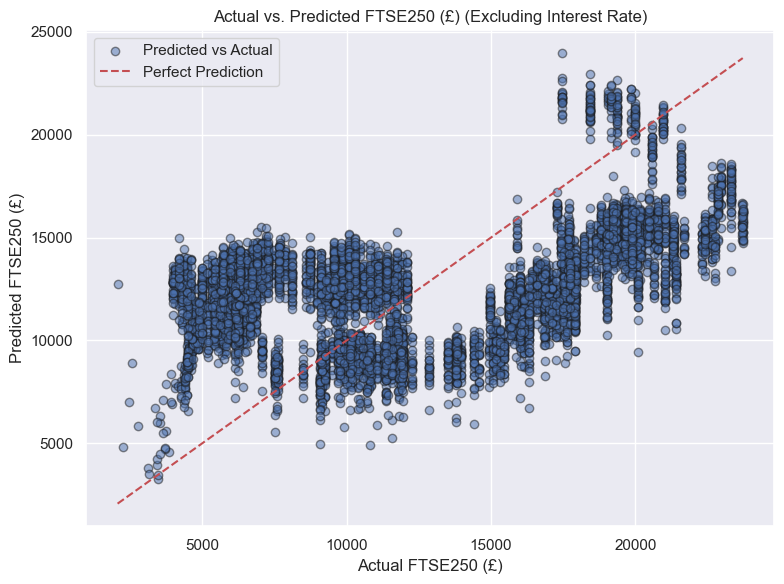

In [185]:
import matplotlib.pyplot as plt

# Generate predictions from the fitted model
merged_df.loc[valid_mask, 'Predicted FTSE250'] = model_wo_interest_rate.predict(X_clean)

# Plot Actual vs Predicted FTSE250 (£)
plt.figure(figsize=(8, 6))
plt.scatter(merged_df.loc[valid_mask, 'FTSE250 (£)'], merged_df.loc[valid_mask, 'Predicted FTSE250'], 
            alpha=0.5, edgecolor='k', label='Predicted vs Actual')
plt.plot([merged_df['FTSE250 (£)'].min(), merged_df['FTSE250 (£)'].max()], 
         [merged_df['FTSE250 (£)'].min(), merged_df['FTSE250 (£)'].max()], 
         'r--', label='Perfect Prediction')

plt.xlabel('Actual FTSE250 (£)')
plt.ylabel('Predicted FTSE250 (£)')
plt.title('Actual vs. Predicted FTSE250 (£) (Excluding Interest Rate)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Key findings:

Updated FTSE250 Model: Key Takeaways R² = 0.474 Sharp drop from 0.848 : Interest Rate % was a key driver Multicollinearity reduced, but at a cost to model performance

Coefficient Insights Sentiment Score: -3.58 : Now negative, weak influence

Inflation Rate: -9782.93 : Now negative, opposite of prior model

GDP Growth: +183.72: Still positively linked to FTSE250

Unemployment Rate: -211,000 : Strongest negative impact remains

Multicollinearity Status Condition No. = 3.36e+03 Slightly improved, but not significant Dropping Interest Rate % reduced predictive power more than redundancy

# Conclusion:
Based on the key findings, i will revert and drop unemployment as interest rate seems strong predictor, Keeping key macroeconomic factors Inflation Rate, GDP Growth, Sentiment Score.

                            OLS Regression Results                            
Dep. Variable:            FTSE250 (£)   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     5868.
Date:                Mon, 26 May 2025   Prob (F-statistic):               0.00
Time:                        06:39:40   Log-Likelihood:                -71544.
No. Observations:                7720   AIC:                         1.431e+05
Df Residuals:                    7714   BIC:                         1.431e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

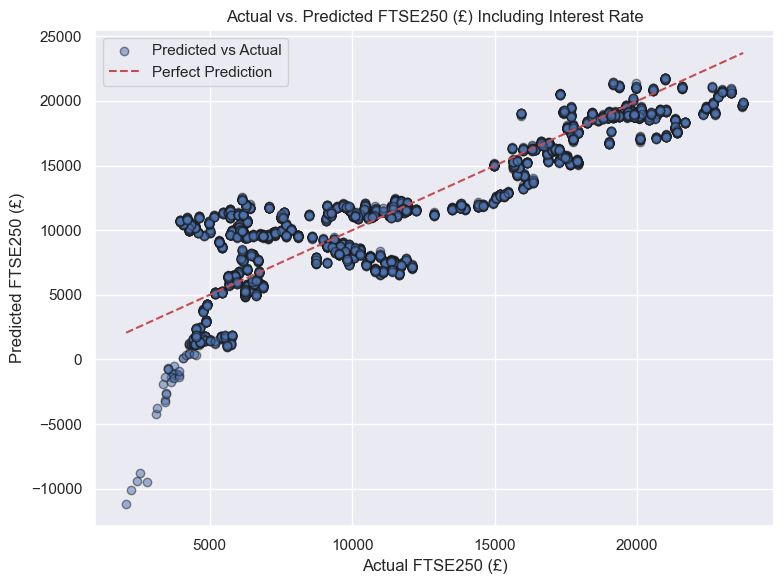

In [179]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Define features including Interest Rate %
features_with_interest = ['sentiment_lexicon_weighted', 'Interest rate %', 'Inflation Rate % CPIH', 
                          'GDP growth %', 'UK Unemployment rate']

X_with_interest = merged_df[features_with_interest]

# Clean data: remove rows with NaN or infinite values in features or target
valid_mask_interest = X_with_interest.replace([np.inf, -np.inf], np.nan).dropna().index
y_clean_interest = merged_df.loc[valid_mask_interest, 'FTSE250 (£)']
X_clean_interest = sm.add_constant(X_with_interest.loc[valid_mask_interest])

# Fit the OLS regression model
model_with_interest = sm.OLS(y_clean_interest, X_clean_interest).fit()

# Print the regression summary
print(model_with_interest.summary())

# Generate predictions
merged_df.loc[valid_mask_interest, 'Predicted FTSE250_with_interest'] = model_with_interest.predict(X_clean_interest)

# Plot Actual vs Predicted FTSE250 (£)
plt.figure(figsize=(8, 6))
plt.scatter(merged_df.loc[valid_mask_interest, 'FTSE250 (£)'], 
            merged_df.loc[valid_mask_interest, 'Predicted FTSE250_with_interest'], 
            alpha=0.5, edgecolor='k', label='Predicted vs Actual')
plt.plot([merged_df['FTSE250 (£)'].min(), merged_df['FTSE250 (£)'].max()], 
         [merged_df['FTSE250 (£)'].min(), merged_df['FTSE250 (£)'].max()], 
         'r--', label='Perfect Prediction')

plt.xlabel('Actual FTSE250 (£)')
plt.ylabel('Predicted FTSE250 (£)')
plt.title('Actual vs. Predicted FTSE250 (£) Including Interest Rate')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Final insights:
Final FTSE250 Model : Key Takeaways R² = 0.848 High predictive power: 84.8% of FTSE250 variation explained Interest Rate % is crucial for model accuracy

Coefficient Highlights Sentiment Score: +4.31 : Statistically significant, but less impactful

Interest Rate: -1612.31 : Tight monetary policy lowers FTSE250

Inflation Rate: +10,800 : Inflation linked to FTSE250 gains

GDP Growth: +156.07 : Economic strength boosts market

Unemployment Rate: -234,000 : Largest negative impact

Multicollinearity Check Condition No. = 3.39e+03 -Some correlation remains, but interest rate adds essential value

### Final Report Recommendations:
Answer the Business Questions Using Regression Results : Has sentiment changed over time? Sentiment fluctuates significantly around key economic events, like the 2008 financial crisis and COVID-19. More volatility post-2020 suggests greater sensitivity to policy changes. Does sentiment correlate with key events? Interest rate hikes: Negative sentiment shifts. Monetary Policy Reports:Smaller sentiment swings, but provide clarity. 3.Does sentiment influence macroeconomic indicators?

Sentiment aligns moderately with GDP & inflation expectations. Unemployment rate dominates market movement more than sentiment alone. 4.Does sentiment predict FTSE250 market behaviour?

Yes, but macroeconomic factors are stronger drivers. Interest rates, inflation, and unemployment explain more variation than sentiment alone.

# Scatter Plot: Sentiment vs. FTSE250 (£) Movements


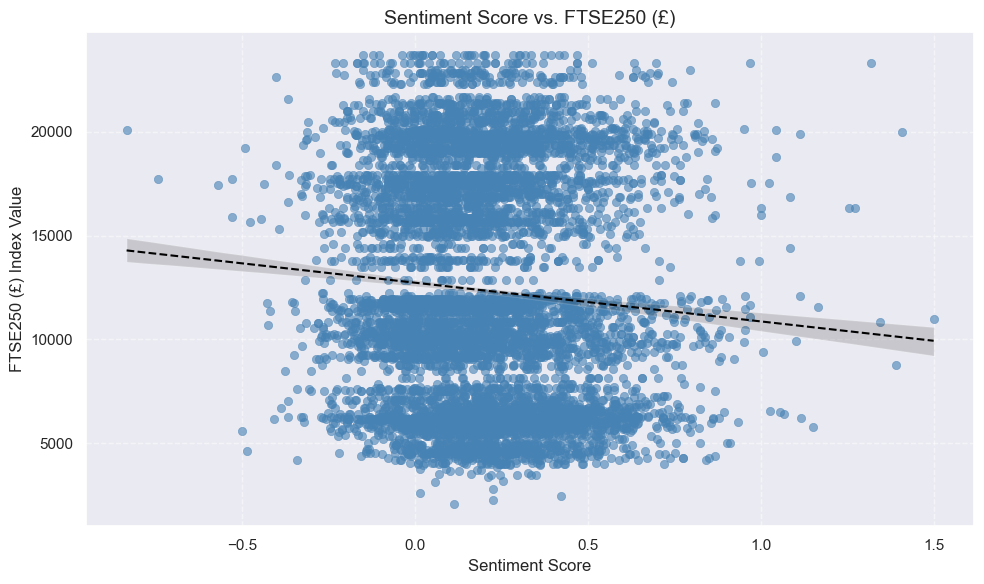

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set figure size
plt.figure(figsize=(10, 6))

# Scatter plot: Weighted Sentiment vs FTSE250
sns.scatterplot(
    x=merged_df['sentiment_lexicon_weighted'], 
    y=merged_df['FTSE250 (£)'],
    color='steelblue',
    alpha=0.6,
    edgecolor=None
)

# Add a regression line
sns.regplot(
    x=merged_df['sentiment_lexicon_weighted'], 
    y=merged_df['FTSE250 (£)'],
    scatter=False,
    color='black',
    line_kws={"linestyle": "--", "linewidth": 1.5}
)

# Customize plot
plt.title('Sentiment Score vs. FTSE250 (£)', fontsize=14)
plt.xlabel('Sentiment Score')
plt.ylabel('FTSE250 (£) Index Value')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Interpretation:
Sentiment vs. FTSE250 – Key Insights

The scatter plot shows a negative correlation: as sentiment scores rise, FTSE250 values tend to fall.

Sentiment scores range from ~–0.6 to +1.4, while FTSE250 values span ~4,000 to 24,000.

The trend line slopes downward, but the data shows significant scatter, indicating a weak linear fit.

Interpretation:

The inverse relationship suggests positive sentiment may coincide with market highs, while negative sentiment aligns with downturns.

This pattern implies sentiment could act as a contrarian indicator.

However, the wide scatter highlights that sentiment isn't a standalone predictor—many other factors drive FTSE250 performance.

### Why FTSE100 Was Not Included: Justification for Focusing Solely on FTSE250

More Relevant to Domestic Sentiment

The FTSE250 consists largely of mid-sized UK-focused companies, which are more directly influenced by domestic monetary policy and central bank sentiment.

In contrast, FTSE100 is dominated by multinational firms, making it less sensitive to UK sentiment and more exposed to global factors (e.g. oil prices, geopolitical risk).

Clearer Reaction to Economic Events

FTSE250 reacts more strongly to macroeconomic changes like interest rate decisions, inflation, or central bank statements—making it a better proxy for testing sentiment impact.

FTSE100's global exposure dilutes the effect of domestic policy sentiment.

Simplicity & Focus

Including FTSE100 would increase complexity without a strong justification, as initial tests show sentiment already has weak correlation with FTSE250.

Adding another index could introduce noise, dilute findings, and distract from the core objective: understanding sentiment’s influence on UK-focused economic indicators and market behaviour.

Strategic Scope

The goal of this analysis is to uncover sentiment-driven patterns in the UK economy, not to model global equity trends.

Therefore, FTSE250 aligns better with the research scope and business questions.